In [2]:
import os
import re
import glob
import numpy as np
from netCDF4 import Dataset

# ============================================================
# 1) SSW detection
# ============================================================

def count_ssw_events_ubar_2d(
    u_2d,
    dmax_ref=992,
    min_gap_days=10.0,
    min_gap_onset_days=20.0,
    min_duration_days=2.0,
    enforce_march10_cutoff=True,
    march10_step_in_992=640,
    return_debug=False,
):
    u_2d = np.asarray(u_2d, float)
    years, n_per_year = u_2d.shape

    steps_per_day = 4.0 * (n_per_year / float(dmax_ref))

    min_gap_steps       = max(1, int(round(min_gap_days * steps_per_day)))
    min_gap_onset_steps = max(1, int(round(min_gap_onset_days * steps_per_day)))
    min_dur_steps       = max(1, int(round(min_duration_days * steps_per_day)))

    cutoff_step = int(round(march10_step_in_992 / float(dmax_ref) * n_per_year))

    neg = (u_2d < 0.0)
    neg_flat = neg.ravel()
    T = neg_flat.size

    onsets = []
    ends = []

    if T == 0:
        return (0, [], {}) if return_debug else (0, [])

    if neg_flat[0]:
        onsets.append(0)

    for t in range(1, T):
        if neg_flat[t] and not neg_flat[t-1]:
            onsets.append(t)
        if (not neg_flat[t]) and neg_flat[t-1]:
            ends.append(t-1)

    if neg_flat[-1]:
        ends.append(T-1)

    m = min(len(onsets), len(ends))
    onsets = onsets[:m]
    ends = ends[:m]
    raw_events = [(s, e) for s, e in zip(onsets, ends) if e > s]

    filtered = []
    for s, e in raw_events:
        if (e - s + 1) < min_dur_steps:
            continue
        if ((e + 1) % n_per_year) == 0:
            continue
        filtered.append((s, e))

    final_events = []
    for s, e in filtered:
        if not final_events:
            final_events.append((s, e))
            continue

        s_prev, e_prev = final_events[-1]
        ok_gap_prev_end   = (s - e_prev) >= min_gap_steps
        ok_gap_prev_onset = (s - s_prev) >= min_gap_onset_steps

        ok_gap_prev2_end = True
        if len(final_events) >= 2:
            s_prev2, e_prev2 = final_events[-2]
            ok_gap_prev2_end = (s - e_prev2) >= min_gap_steps

        if ok_gap_prev_end and ok_gap_prev2_end and ok_gap_prev_onset:
            final_events.append((s, e))

    if enforce_march10_cutoff:
        kept = []
        for s, e in final_events:
            j = s % n_per_year
            if j > cutoff_step:
                continue
            kept.append((s, e))
        final_events = kept

    n_ssw = len(final_events)

    debug = dict(
        steps_per_day=steps_per_day,
        min_gap_steps=min_gap_steps,
        min_gap_onset_steps=min_gap_onset_steps,
        min_dur_steps=min_dur_steps,
        cutoff_step=cutoff_step,
        raw_events=raw_events,
        filtered_events=filtered,
        final_events=final_events,
    )

    return (n_ssw, final_events, debug) if return_debug else (0 + n_ssw, final_events)


# ============================================================
# 2) config
# ============================================================

ROOT = "/nas/smliu01/1d_model"
SAVE_DIR = "./ssw_scan_results"
os.makedirs(SAVE_DIR, exist_ok=True)

FORCING_DIRS = [
    "scale_0p50",
    "scale_0p80",
    "scale_1p00",
    "scale_1p20",
    "scale_1p50",
    "scale_2p00",
]

ALPHA_DIR_MAP = {
    "output_sweep_a_n40": -0.4,
    "output_sweep_a_n20": -0.2,
    "output_sweep":        0.0,
    "output_sweep_a_20":   0.2,
    "output_sweep_a_40":   0.4,
}

SHEAR_DIR_MAP = {
    "output_sweep_b_n40": -0.4,
    "output_sweep_b_n20": -0.2,
    "output_sweep_b_00":   0.0,
    "output_sweep_b_20":   0.2,
    "output_sweep_b_40":   0.4,
}

YR = 1000
LEVEL_INDEX = 110
N_PER_YEAR = 160
UBAR_VAR_NAME = "ubar"

MIN_GAP_DAYS = 10.0
MIN_GAP_ONSET_DAYS = 20.0
MIN_DURATION_DAYS = 2.0
ENFORCE_MARCH10 = True
MARCH10_STEP_IN_992 = 640
DMAX_REF = 992


# ============================================================
# 3) helpers
# ============================================================

def parse_scale_name(scale_name):
    return float(scale_name.replace("scale_", "").replace("p", "."))

def find_ubar_file(ens_dir):
    patterns = [
        os.path.join(ens_dir, "uout*.nc"),
        os.path.join(ens_dir, "*uout*.nc"),
        os.path.join(ens_dir, "*.nc"),
    ]

    files = []
    for pat in patterns:
        files.extend(glob.glob(pat))

    files = sorted(set(files))

    uout_files = [f for f in files if "uout" in os.path.basename(f)]
    if len(uout_files) > 0:
        return uout_files[0]

    if len(files) > 0:
        return files[0]

    return None

def list_ensemble_dirs(scale_dir):
    all_subdirs = sorted([
        os.path.join(scale_dir, d)
        for d in os.listdir(scale_dir)
        if os.path.isdir(os.path.join(scale_dir, d))
    ])

    ens_dirs = []
    for d in all_subdirs:
        if re.match(r"ens\d+", os.path.basename(d)):
            ens_dirs.append(d)

    if len(ens_dirs) == 0:
        ens_dirs = all_subdirs

    return sorted(ens_dirs)

def compute_member_ssw_frequency(ubar_file):
    with Dataset(ubar_file, "r") as nc:
        ubar = np.array(nc.variables[UBAR_VAR_NAME])

    u1d = ubar[LEVEL_INDEX, :]
    expected_len = YR * N_PER_YEAR
    if u1d.size != expected_len:
        raise ValueError(
            f"{ubar_file}\n"
            f"ubar length = {u1d.size}, expected = {expected_len}"
        )

    u2d = u1d.reshape(YR, N_PER_YEAR)

    n_ssw, events = count_ssw_events_ubar_2d(
        u2d,
        dmax_ref=DMAX_REF,
        min_gap_days=MIN_GAP_DAYS,
        min_gap_onset_days=MIN_GAP_ONSET_DAYS,
        min_duration_days=MIN_DURATION_DAYS,
        enforce_march10_cutoff=ENFORCE_MARCH10,
        march10_step_in_992=MARCH10_STEP_IN_992,
        return_debug=False,
    )

    return n_ssw / YR, n_ssw


def scan_parameter_grid(root, param_dir_map, forcing_dirs, scan_name="scan", verbose=True):
    param_values = sorted(param_dir_map.values())
    forcing_values = [parse_scale_name(x) for x in forcing_dirs]

    mean_freq_mat = np.full((len(forcing_values), len(param_values)), np.nan)
    std_freq_mat  = np.full((len(forcing_values), len(param_values)), np.nan)
    nmem_mat      = np.zeros((len(forcing_values), len(param_values)), dtype=int)

    value_to_dir = {v: k for k, v in param_dir_map.items()}

    for j, param_value in enumerate(param_values):
        big_dir_name = value_to_dir[param_value]
        big_dir = os.path.join(root, big_dir_name)

        if not os.path.isdir(big_dir):
            print(f"[WARN] Missing parameter directory: {big_dir}")
            continue

        print("=" * 80)
        print(f"[INFO] {scan_name}: param={param_value:+.3f}, dir={big_dir_name}")

        for i, scale_name in enumerate(forcing_dirs):
            forcing_value = parse_scale_name(scale_name)
            scale_dir = os.path.join(big_dir, scale_name)

            if not os.path.isdir(scale_dir):
                print(f"  [WARN] Missing forcing directory: {scale_dir}")
                continue

            ens_dirs = list_ensemble_dirs(scale_dir)
            member_freqs = []

            print(f"  [INFO] forcing={forcing_value:.2f}, members={len(ens_dirs)}")

            for ens_dir in ens_dirs:
                ens_name = os.path.basename(ens_dir)
                ubar_file = find_ubar_file(ens_dir)

                if ubar_file is None:
                    print(f"    [WARN] No file in {ens_dir}")
                    continue

                try:
                    freq, n_ssw = compute_member_ssw_frequency(ubar_file)
                    member_freqs.append(freq)
                    if verbose:
                        print(f"    [{ens_name}] n_ssw={n_ssw:4d}, freq={freq:.4f}")
                except Exception as e:
                    print(f"    [ERROR] {ens_name}: {e}")

            member_freqs = np.asarray(member_freqs, float)

            if member_freqs.size > 0:
                mean_freq_mat[i, j] = np.mean(member_freqs)
                std_freq_mat[i, j]  = np.std(member_freqs, ddof=1) if member_freqs.size >= 2 else 0.0
                nmem_mat[i, j]      = member_freqs.size

                print(f"  [DONE] mean={mean_freq_mat[i,j]:.4f}, std={std_freq_mat[i,j]:.4f}, n={nmem_mat[i,j]}")
            else:
                print(f"  [WARN] No valid members for forcing={forcing_value:.2f}, param={param_value:+.3f}")

    save_file = os.path.join(SAVE_DIR, f"{scan_name}.npz")
    np.savez(
        save_file,
        param_values=np.asarray(param_values, float),
        forcing_values=np.asarray(forcing_values, float),
        mean_freq_mat=mean_freq_mat,
        std_freq_mat=std_freq_mat,
        nmem_mat=nmem_mat,
    )
    print(f"\nSaved to: {save_file}")

    return param_values, forcing_values, mean_freq_mat, std_freq_mat, nmem_mat


# ============================================================
# 4) run
# ============================================================

scan_parameter_grid(
    root=ROOT,
    param_dir_map=ALPHA_DIR_MAP,
    forcing_dirs=FORCING_DIRS,
    scan_name="alpha_scan",
    verbose=True,
)

scan_parameter_grid(
    root=ROOT,
    param_dir_map=SHEAR_DIR_MAP,
    forcing_dirs=FORCING_DIRS,
    scan_name="shear_scan",
    verbose=True,
)

[INFO] alpha_scan: param=-0.400, dir=output_sweep_a_n40
  [INFO] forcing=0.50, members=10
    [ens00] n_ssw=  26, freq=0.0260
    [ens01] n_ssw=  43, freq=0.0430
    [ens02] n_ssw=  41, freq=0.0410
    [ens03] n_ssw=  66, freq=0.0660
    [ens04] n_ssw=  46, freq=0.0460
    [ens05] n_ssw=  47, freq=0.0470
    [ens06] n_ssw=  36, freq=0.0360
    [ens07] n_ssw=  40, freq=0.0400
    [ens08] n_ssw=  48, freq=0.0480
    [ens09] n_ssw=  38, freq=0.0380
  [DONE] mean=0.0431, std=0.0103, n=10
  [INFO] forcing=0.80, members=10
    [ens00] n_ssw= 356, freq=0.3560
    [ens01] n_ssw= 358, freq=0.3580
    [ens02] n_ssw= 347, freq=0.3470
    [ens03] n_ssw= 391, freq=0.3910
    [ens04] n_ssw= 157, freq=0.1570
    [ens05] n_ssw= 332, freq=0.3320
    [ens06] n_ssw= 342, freq=0.3420
    [ens07] n_ssw= 385, freq=0.3850
    [ens08] n_ssw= 322, freq=0.3220
    [ens09] n_ssw= 360, freq=0.3600
  [DONE] mean=0.3350, std=0.0661, n=10
  [INFO] forcing=1.00, members=10
    [ens00] n_ssw= 857, freq=0.8570
    [ens

([-0.4, -0.2, 0.0, 0.2, 0.4],
 [0.5, 0.8, 1.0, 1.2, 1.5, 2.0],
 array([[0.1029, 0.0496, 0.0293, 0.019 , 0.01  ],
        [0.5235, 0.3157, 0.2473, 0.1819, 0.0972],
        [1.0419, 0.7548, 0.6705, 0.5023, 0.2813],
        [1.4979, 1.2016, 1.1139, 0.8241, 0.4563],
        [2.1871, 2.0084, 1.9373, 1.3964, 0.7736],
        [2.5631, 2.6429, 2.6996, 1.9581, 1.1371]]),
 array([[0.01646849, 0.01208488, 0.00758727, 0.00547723, 0.00405518],
        [0.11406163, 0.06429973, 0.05033896, 0.03640345, 0.02021441],
        [0.02947862, 0.03643198, 0.03441334, 0.03588887, 0.03686326],
        [0.226661  , 0.1773297 , 0.15680593, 0.1168441 , 0.06888162],
        [0.04142047, 0.05714932, 0.06365715, 0.07039444, 0.03329731],
        [0.05030893, 0.05397211, 0.06044502, 0.05006762, 0.06565474]]),
 array([[10, 10, 10, 10, 10],
        [10, 10, 10, 10, 10],
        [10, 10, 10, 10, 10],
        [10, 10, 10, 10, 10],
        [10, 10, 10, 10, 10],
        [10, 10, 10, 10, 10]]))

In [3]:
# import numpy as np
# import matplotlib.pyplot as plt

# # ============================================================
# # 1) load helper
# # ============================================================

# def load_scan_result(npz_file):
#     data = np.load(npz_file)
#     param_values   = data["param_values"]
#     forcing_values = data["forcing_values"]
#     mean_freq_mat  = data["mean_freq_mat"]
#     std_freq_mat   = data["std_freq_mat"]
#     nmem_mat       = data["nmem_mat"]
#     return param_values, forcing_values, mean_freq_mat, std_freq_mat, nmem_mat


# # ============================================================
# # 2) side-by-side plot with one shared colorbar
# # ============================================================

# # def plot_two_heatmaps_contour_shared_cbar(
# #     alpha_values,
# #     forcing_values_alpha,
# #     alpha_mean,
# #     shear_values,
# #     forcing_values_shear,
# #     shear_mean,
# #     xlabel1="urad alpha",
# #     xlabel2="urad shear",
# #     ylabel="Forcing amplitude",
# #     title1="SSW frequency: alpha vs forcing amplitude",
# #     title2="SSW frequency: shear vs forcing amplitude",
# #     cmap="RdBu_r",
# #     levels=12,
# #     annotate=False,
# # ):
# #     #  color scale
# #     global_min = np.nanmin([np.nanmin(alpha_mean), np.nanmin(shear_mean)])
# #     global_max = np.nanmax([np.nanmax(alpha_mean), np.nanmax(shear_mean)])

# #     #  levels
# #     level_values = np.linspace(global_min, global_max, levels)

# #     X1, Y1 = np.meshgrid(alpha_values, forcing_values_alpha)
# #     X2, Y2 = np.meshgrid(shear_values, forcing_values_shear)

# #     fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), sharey=True)

# #     # ---- left: alpha ----
# #     cf1 = axes[0].contourf(
# #         X1, Y1, alpha_mean,
# #         levels=level_values,
# #         cmap=cmap,
# #         extend="both"
# #     )
# #     cs1 = axes[0].contour(
# #         X1, Y1, alpha_mean,
# #         levels=level_values,
# #         colors="k",
# #         linewidths=0.8
# #     )
# #     axes[0].clabel(cs1, inline=True, fontsize=8, fmt="%.3f")

# #     if annotate:
# #         for i, fy in enumerate(forcing_values_alpha):
# #             for j, px in enumerate(alpha_values):
# #                 val = alpha_mean[i, j]
# #                 if np.isfinite(val):
# #                     axes[0].text(px, fy, f"{val:.3f}",
# #                                  ha="center", va="center", fontsize=8)

# #     axes[0].set_xlabel(xlabel1, fontsize=12)
# #     axes[0].set_ylabel(ylabel, fontsize=12)
# #     axes[0].set_title(title1, fontsize=12)
# #     axes[0].set_xticks(alpha_values)
# #     axes[0].set_yticks(forcing_values_alpha)

# #     # ---- right: shear ----
# #     cf2 = axes[1].contourf(
# #         X2, Y2, shear_mean,
# #         levels=level_values,
# #         cmap=cmap,
# #         extend="both"
# #     )
# #     cs2 = axes[1].contour(
# #         X2, Y2, shear_mean,
# #         levels=level_values,
# #         colors="k",
# #         linewidths=0.8
# #     )
# #     axes[1].clabel(cs2, inline=True, fontsize=8, fmt="%.3f")

# #     if annotate:
# #         for i, fy in enumerate(forcing_values_shear):
# #             for j, px in enumerate(shear_values):
# #                 val = shear_mean[i, j]
# #                 if np.isfinite(val):
# #                     axes[1].text(px, fy, f"{val:.3f}",
# #                                  ha="center", va="center", fontsize=8)

# #     axes[1].set_xlabel(xlabel2, fontsize=12)
# #     axes[1].set_title(title2, fontsize=12)
# #     axes[1].set_xticks(shear_values)
# #     axes[1].set_yticks(forcing_values_shear)

# #     # ---- one shared colorbar ----
# #     cbar = fig.colorbar(
# #         cf2,
# #         ax=axes,
# #         orientation="vertical",
# #         fraction=0.046,
# #         pad=0.04
# #     )
# #     cbar.set_label("Ensemble mean SSW frequency", fontsize=12)

# #     plt.tight_layout()
# #     plt.show()


# def plot_two_heatmaps_contour_shared_cbar(
#     alpha_values,
#     forcing_values_alpha,
#     alpha_mean,
#     shear_values,
#     forcing_values_shear,
#     shear_mean,
#     xlabel1="urad alpha",
#     xlabel2="urad shear",
#     ylabel="Forcing amplitude",
#     title1="SSW frequency: alpha vs forcing amplitude",
#     title2="SSW frequency: shear vs forcing amplitude",
#     cmap="RdBu_r",
#     levels=12,
#     annotate=False,
# ):
#     global_min = 0   #np.nanmin([np.nanmin(alpha_mean), np.nanmin(shear_mean)])
#     global_max = 2.5 #np.nanmax([np.nanmax(alpha_mean), np.nanmax(shear_mean)])
#     level_values = np.linspace(global_min, global_max, levels)

#     X1, Y1 = np.meshgrid(alpha_values, forcing_values_alpha)
#     X2, Y2 = np.meshgrid(shear_values, forcing_values_shear)

#     fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), sharey=True)

#     # ---- left ----
#     cf1 = axes[0].contourf(X1, Y1, alpha_mean, levels=level_values, cmap=cmap, extend="both")
#     cs1 = axes[0].contour(X1, Y1, alpha_mean, levels=level_values, colors="k", linewidths=0.8)
#     axes[0].clabel(cs1, inline=True, fontsize=8, fmt="%.3f")
#     axes[0].set_xlabel(xlabel1, fontsize=12)
#     axes[0].set_ylabel(ylabel, fontsize=12)
#     #axes[0].set_title(title1, fontsize=12)
#     axes[0].set_xticks(alpha_values)
#     axes[0].set_yticks(forcing_values_alpha)

#     # ---- right ----
#     cf2 = axes[1].contourf(X2, Y2, shear_mean, levels=level_values, cmap=cmap, extend="both")
#     cs2 = axes[1].contour(X2, Y2, shear_mean, levels=level_values, colors="black", linewidths=0.8)
#     axes[1].clabel(cs2, inline=True, fontsize=8, fmt="%.3f",colors="black")
#     axes[1].set_xlabel(xlabel2, fontsize=12)
#     #axes[1].set_title(title2, fontsize=12)
#     axes[1].set_xticks(shear_values)
#     axes[1].set_yticks(forcing_values_shear)

#     # ---- panel labels (a), (b) ----
#     axes[0].text(
#         -0.05, 1.08, "(a)",
#         transform=axes[0].transAxes,
#         fontsize=13, 
#         va="top", ha="left"
#     )

#     axes[1].text(
#         -0.05, 1.08, "(b)",
#         transform=axes[1].transAxes,
#         fontsize=13, 
#         va="top", ha="left"
#     )

#     # ----  colorbar  ----
#     fig.subplots_adjust(right=0.88, wspace=0.08)

#     # ----  colorbar ----
#     cax = fig.add_axes([0.90, 0.14, 0.018, 0.72])
#     cbar = fig.colorbar(cf2, cax=cax)
#     cbar.set_label("Ensemble mean SSW frequency", fontsize=12)

#     return fig


# # ============================================================
# # 3) load alpha
# # ============================================================

# alpha_file = "./ssw_scan_results/alpha_scan.npz"
# alpha_values, forcing_values, alpha_mean, alpha_std, alpha_nmem = load_scan_result(alpha_file)

# # ============================================================
# # 4) load shear
# # ============================================================

# shear_file = "./ssw_scan_results/shear_scan.npz"
# shear_values, forcing_values2, shear_mean, shear_std, shear_nmem = load_scan_result(shear_file)

# # ============================================================
# # 5) plot together
# # ============================================================

# fig = plot_two_heatmaps_contour_shared_cbar(
#     alpha_values=alpha_values,
#     forcing_values_alpha=forcing_values,
#     alpha_mean=alpha_mean,
#     shear_values=shear_values,
#     forcing_values_shear=forcing_values2,
#     shear_mean=shear_mean,

#     xlabel1=r"Upper response, $\gamma_{\mathrm{upper}}$",
#     #title1=r"SSW frequency",

#     xlabel2=r"Lower/middle response, $\gamma_{\mathrm{lowmid}}$",
#     #title2=r"SSW frequency",

#     ylabel="Forcing amplitude",
#     cmap="RdBu_r",
#     levels=17,
#     annotate=False,
# )

# fig.savefig("para_sweep_comparison.png", dpi=600, bbox_inches="tight")
# plt.show()

Upper Delta uRAD range: -7.2944337879760255 7.294433803632266
Low/mid Delta uRAD range: -5.192641798409429 5.192641800091032


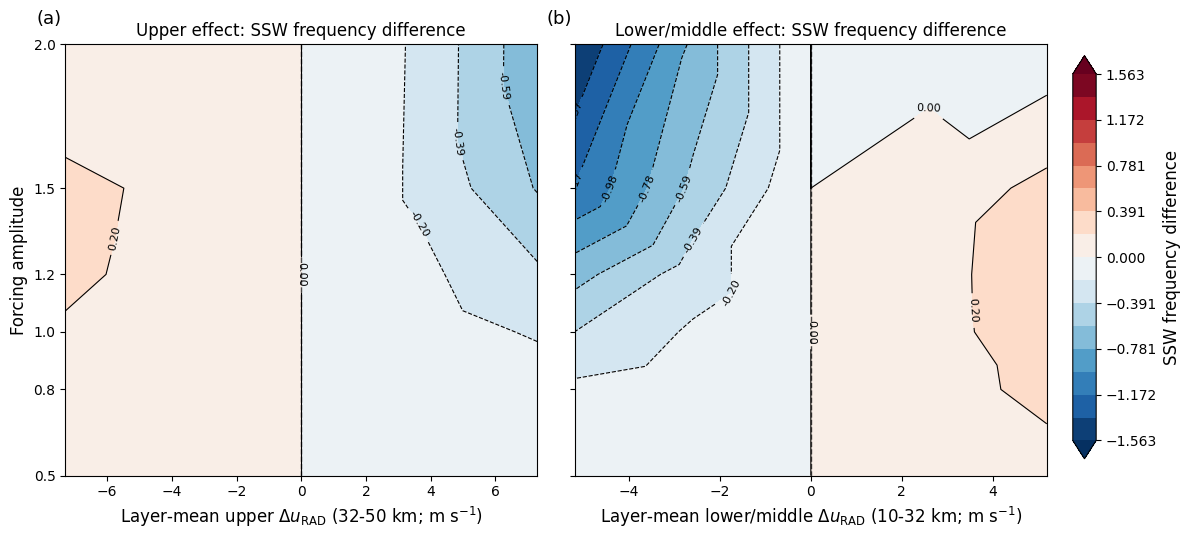

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset

# ============================================================
# 0) paths and settings
# ============================================================

SAVE_DIR = "./ssw_scan_results"
URAD_SWEEP_DIR = "/scratch/smliu01/1d_model/urad_parameter_sweep_clean"

alpha_file = os.path.join(SAVE_DIR, "alpha_scan.npz")
shear_file = os.path.join(SAVE_DIR, "shear_scan.npz")

UPPER_ZMIN = 32.0
UPPER_ZMAX = 50.0

LOWMID_ZMIN = 10.0
LOWMID_ZMAX = 32.0

URAD_VAR = "urad"
HEIGHT_VAR = "height"


# ============================================================
# 1) helpers
# ============================================================

def load_scan_result(npz_file):
    data = np.load(npz_file)
    return (
        data["param_values"],
        data["forcing_values"],
        data["mean_freq_mat"],
        data["std_freq_mat"],
        data["nmem_mat"],
    )


def format_gamma(gamma):
    """
    Match the file naming in urad-generation code:
      -0.2 -> m0p20
       0.4 -> 0p40
    """
    if gamma < 0:
        return "m" + f"{abs(gamma):.2f}".replace(".", "p")
    return f"{gamma:.2f}".replace(".", "p")


def read_layermean_urad(path, zmin_km, zmax_km,
                        include_lower=True, include_upper=True):
    with Dataset(path, "r") as ds:
        urad = np.asarray(ds[URAD_VAR][:], dtype=float)
        height = np.asarray(ds[HEIGHT_VAR][:], dtype=float)

    if include_lower:
        mask_low = height >= zmin_km
    else:
        mask_low = height > zmin_km

    if include_upper:
        mask_high = height <= zmax_km
    else:
        mask_high = height < zmax_km

    idx = np.where(mask_low & mask_high)[0]

    if len(idx) == 0:
        raise ValueError(
            f"No height levels in {zmin_km}-{zmax_km} km for {path}"
        )

    urad_layer = urad[idx, :, :]

    # average over height, year, seasonal time
    return float(np.nanmean(urad_layer))


def get_sweepA_file(gamma_upper, gamma_lowmid=0.0):
    tag_u = format_gamma(gamma_upper)
    tag_l = format_gamma(gamma_lowmid)
    return os.path.join(
        URAD_SWEEP_DIR,
        f"urad_sweepA_gU_{tag_u}_gL_{tag_l}.nc"
    )


def get_sweepB_file(gamma_lowmid, gamma_upper=0.4):
    tag_u = format_gamma(gamma_upper)
    tag_l = format_gamma(gamma_lowmid)
    return os.path.join(
        URAD_SWEEP_DIR,
        f"urad_sweepB_gU_{tag_u}_gL_{tag_l}.nc"
    )


# ============================================================
# 2) load SSW frequency scans
# ============================================================

alpha_values, forcing_values_alpha, alpha_mean, alpha_std, alpha_nmem = load_scan_result(alpha_file)
shear_values, forcing_values_shear, shear_mean, shear_std, shear_nmem = load_scan_result(shear_file)


# ============================================================
# 3) SSW frequency differences
# ============================================================

# Sweep A: upper effect relative to gamma_upper = 0
idx_alpha_ref = np.argmin(np.abs(alpha_values - 0.0))
upper_effect_mat = alpha_mean - alpha_mean[:, idx_alpha_ref][:, None]

# Sweep B: low/mid effect relative to gamma_lowmid = 0
idx_shear_ref = np.argmin(np.abs(shear_values - 0.0))
lowmid_effect_mat = shear_mean - shear_mean[:, idx_shear_ref][:, None]


# ============================================================
# 4) compute Delta uRAD matrices
# ============================================================

# ---------- Sweep A: upper Delta uRAD ----------
urad_upper_abs = np.full_like(alpha_mean, np.nan, dtype=float)

for j, gamma_upper in enumerate(alpha_values):
    path = get_sweepA_file(gamma_upper, gamma_lowmid=0.0)

    if not os.path.exists(path):
        raise FileNotFoundError(path)

    val = read_layermean_urad(
        path,
        UPPER_ZMIN,
        UPPER_ZMAX,
        include_lower=True,
        include_upper=True
    )

    # same uRAD for all forcing amplitudes
    urad_upper_abs[:, j] = val

du_upper_mat = urad_upper_abs - urad_upper_abs[:, idx_alpha_ref][:, None]


# ---------- Sweep B: lower/middle Delta uRAD ----------
urad_lowmid_abs = np.full_like(shear_mean, np.nan, dtype=float)

for j, gamma_lowmid in enumerate(shear_values):
    path = get_sweepB_file(gamma_lowmid, gamma_upper=0.0)

    if not os.path.exists(path):
        raise FileNotFoundError(path)

    val = read_layermean_urad(
        path,
        LOWMID_ZMIN,
        LOWMID_ZMAX,
        include_lower=True,
        include_upper=False   # same as Fig. 1: 10 <= z < 32 km
    )

    # same uRAD for all forcing amplitudes
    urad_lowmid_abs[:, j] = val

du_lowmid_mat = urad_lowmid_abs - urad_lowmid_abs[:, idx_shear_ref][:, None]


print("Upper Delta uRAD range:",
      np.nanmin(du_upper_mat), np.nanmax(du_upper_mat))

print("Low/mid Delta uRAD range:",
      np.nanmin(du_lowmid_mat), np.nanmax(du_lowmid_mat))


# ============================================================
# 5) plot
# ============================================================

def plot_delta_urad_response(
    du_upper_mat,
    du_lowmid_mat,
    forcing_values_alpha,
    forcing_values_shear,
    upper_effect_mat,
    lowmid_effect_mat,
    levels=17,
    cmap="RdBu_r",
    save_name="para_sweep_delta_urad_response.png"
):

    vmax = np.nanmax([
        np.nanmax(np.abs(upper_effect_mat)),
        np.nanmax(np.abs(lowmid_effect_mat))
    ])
    vmin = -vmax
    level_values = np.linspace(vmin, vmax, levels)

    Y_upper = np.repeat(
        forcing_values_alpha[:, None],
        du_upper_mat.shape[1],
        axis=1
    )

    Y_lowmid = np.repeat(
        forcing_values_shear[:, None],
        du_lowmid_mat.shape[1],
        axis=1
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), sharey=True)

    # --------------------------------------------------------
    # (a) upper effect
    # --------------------------------------------------------
    x1 = du_upper_mat.flatten()
    y1 = Y_upper.flatten()
    z1 = upper_effect_mat.flatten()

    valid1 = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(z1)

    cf1 = axes[0].tricontourf(
        x1[valid1],
        y1[valid1],
        z1[valid1],
        levels=level_values,
        cmap=cmap,
        extend="both"
    )

    cs1 = axes[0].tricontour(
        x1[valid1],
        y1[valid1],
        z1[valid1],
        levels=level_values,
        colors="k",
        linewidths=0.8
    )

    axes[0].clabel(cs1, inline=True, fontsize=8, fmt="%.2f")

    axes[0].axvline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    axes[0].set_xlabel(
        rf"Layer-mean upper $\Delta u_{{\mathrm{{RAD}}}}$ "
        rf"({UPPER_ZMIN:.0f}-{UPPER_ZMAX:.0f} km; m s$^{{-1}}$)",
        fontsize=12
    )
    axes[0].set_ylabel("Forcing amplitude", fontsize=12)
    axes[0].set_title("Upper effect: SSW frequency difference", fontsize=12)
    axes[0].set_yticks(forcing_values_alpha)

    axes[0].text(
        -0.06, 1.08, "(a)",
        transform=axes[0].transAxes,
        fontsize=13,
        va="top",
        ha="left"
    )

    # --------------------------------------------------------
    # (b) lower/middle effect
    # --------------------------------------------------------
    x2 = du_lowmid_mat.flatten()
    y2 = Y_lowmid.flatten()
    z2 = lowmid_effect_mat.flatten()

    valid2 = np.isfinite(x2) & np.isfinite(y2) & np.isfinite(z2)

    cf2 = axes[1].tricontourf(
        x2[valid2],
        y2[valid2],
        z2[valid2],
        levels=level_values,
        cmap=cmap,
        extend="both"
    )

    cs2 = axes[1].tricontour(
        x2[valid2],
        y2[valid2],
        z2[valid2],
        levels=level_values,
        colors="k",
        linewidths=0.8
    )

    axes[1].clabel(cs2, inline=True, fontsize=8, fmt="%.2f")

    axes[1].axvline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    axes[1].set_xlabel(
        rf"Layer-mean lower/middle $\Delta u_{{\mathrm{{RAD}}}}$ "
        rf"({LOWMID_ZMIN:.0f}-{LOWMID_ZMAX:.0f} km; m s$^{{-1}}$)",
        fontsize=12
    )
    axes[1].set_title("Lower/middle effect: SSW frequency difference", fontsize=12)
    axes[1].set_yticks(forcing_values_shear)

    axes[1].text(
        -0.06, 1.08, "(b)",
        transform=axes[1].transAxes,
        fontsize=13,
        va="top",
        ha="left"
    )

    # --------------------------------------------------------
    # colorbar
    # --------------------------------------------------------
    fig.subplots_adjust(right=0.88, wspace=0.08)

    cax = fig.add_axes([0.90, 0.14, 0.018, 0.72])
    cbar = fig.colorbar(cf2, cax=cax)
    cbar.set_label("SSW frequency difference", fontsize=12)

    fig.savefig(save_name, dpi=600, bbox_inches="tight")
    plt.show()

    return fig


fig = plot_delta_urad_response(
    du_upper_mat=du_upper_mat,
    du_lowmid_mat=du_lowmid_mat,
    forcing_values_alpha=forcing_values_alpha,
    forcing_values_shear=forcing_values_shear,
    upper_effect_mat=upper_effect_mat,
    lowmid_effect_mat=lowmid_effect_mat,
    levels=17,
    cmap="RdBu_r",
    save_name="para_sweep_delta_urad_response.png"
)

Upper Delta uRAD range: -7.2944337879760255 7.294433803632266
Low/mid Delta uRAD range: -5.192641798409429 5.192641800091032
Upper SSW frequency range: 0.0173 2.7386
Low/mid SSW frequency range: 0.009999999999999998 2.6996


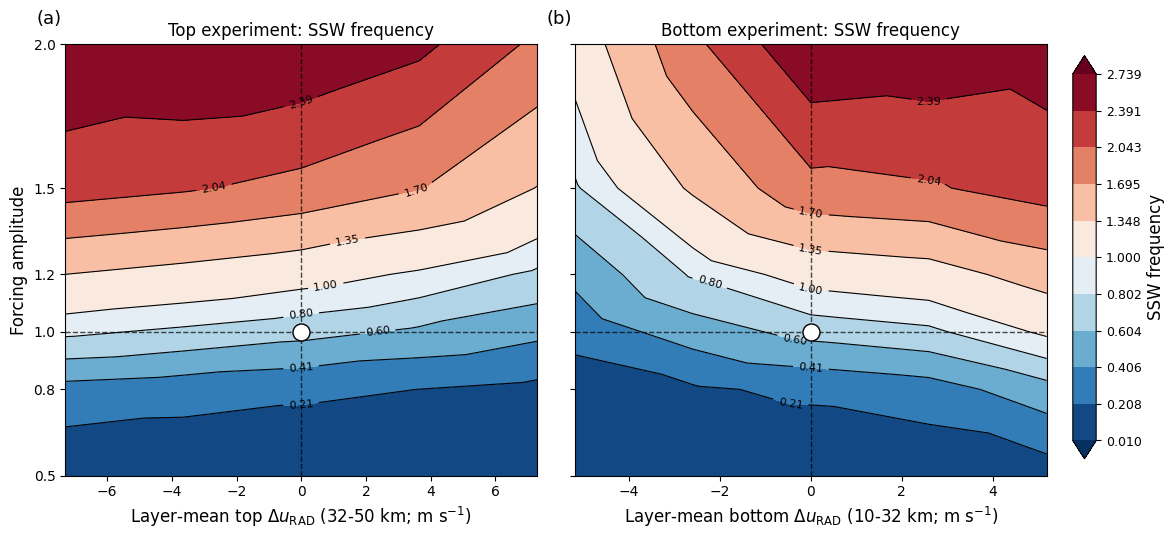

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset

# ============================================================
# 0) paths and settings
# ============================================================

SAVE_DIR = "./ssw_scan_results"
URAD_SWEEP_DIR = "/scratch/smliu01/1d_model/urad_parameter_sweep_clean"

alpha_file = os.path.join(SAVE_DIR, "alpha_scan.npz")
shear_file = os.path.join(SAVE_DIR, "shear_scan.npz")

UPPER_ZMIN = 32.0
UPPER_ZMAX = 50.0

LOWMID_ZMIN = 10.0
LOWMID_ZMAX = 32.0

URAD_VAR = "urad"
HEIGHT_VAR = "height"


# ============================================================
# 1) helpers
# ============================================================

def load_scan_result(npz_file):
    data = np.load(npz_file)
    return (
        data["param_values"],
        data["forcing_values"],
        data["mean_freq_mat"],
        data["std_freq_mat"],
        data["nmem_mat"],
    )


def format_gamma(gamma):
    """
    Match the file naming in urad-generation code:
      -0.2 -> m0p20
       0.4 -> 0p40
    """
    if gamma < 0:
        return "m" + f"{abs(gamma):.2f}".replace(".", "p")
    return f"{gamma:.2f}".replace(".", "p")


def read_layermean_urad(path, zmin_km, zmax_km,
                        include_lower=True, include_upper=True):
    with Dataset(path, "r") as ds:
        urad = np.asarray(ds[URAD_VAR][:], dtype=float)
        height = np.asarray(ds[HEIGHT_VAR][:], dtype=float)

    if include_lower:
        mask_low = height >= zmin_km
    else:
        mask_low = height > zmin_km

    if include_upper:
        mask_high = height <= zmax_km
    else:
        mask_high = height < zmax_km

    idx = np.where(mask_low & mask_high)[0]

    if len(idx) == 0:
        raise ValueError(
            f"No height levels in {zmin_km}-{zmax_km} km for {path}"
        )

    urad_layer = urad[idx, :, :]

    # average over height, year, seasonal time
    return float(np.nanmean(urad_layer))


def get_sweepA_file(gamma_upper, gamma_lowmid=0.0):
    tag_u = format_gamma(gamma_upper)
    tag_l = format_gamma(gamma_lowmid)
    return os.path.join(
        URAD_SWEEP_DIR,
        f"urad_sweepA_gU_{tag_u}_gL_{tag_l}.nc"
    )


def get_sweepB_file(gamma_lowmid, gamma_upper=0.0):
    tag_u = format_gamma(gamma_upper)
    tag_l = format_gamma(gamma_lowmid)
    return os.path.join(
        URAD_SWEEP_DIR,
        f"urad_sweepB_gU_{tag_u}_gL_{tag_l}.nc"
    )


# ============================================================
# 2) load SSW frequency scans
# ============================================================

alpha_values, forcing_values_alpha, alpha_mean, alpha_std, alpha_nmem = load_scan_result(alpha_file)
shear_values, forcing_values_shear, shear_mean, shear_std, shear_nmem = load_scan_result(shear_file)


# ============================================================
# 3) SSW frequency absolute values
# ============================================================

# Sweep A: absolute SSW frequency
upper_ssw_mat = alpha_mean.copy()

# Sweep B: absolute SSW frequency
lowmid_ssw_mat = shear_mean.copy()


# ============================================================
# 4) compute Delta uRAD matrices
# ============================================================

# ---------- Sweep A: upper Delta uRAD ----------
idx_alpha_ref = np.argmin(np.abs(alpha_values - 0.0))
urad_upper_abs = np.full_like(alpha_mean, np.nan, dtype=float)

for j, gamma_upper in enumerate(alpha_values):
    path = get_sweepA_file(gamma_upper, gamma_lowmid=0.0)

    if not os.path.exists(path):
        raise FileNotFoundError(path)

    val = read_layermean_urad(
        path,
        UPPER_ZMIN,
        UPPER_ZMAX,
        include_lower=True,
        include_upper=True
    )

    # same uRAD for all forcing amplitudes
    urad_upper_abs[:, j] = val

du_upper_mat = urad_upper_abs - urad_upper_abs[:, idx_alpha_ref][:, None]


# ---------- Sweep B: lower/middle Delta uRAD ----------
idx_shear_ref = np.argmin(np.abs(shear_values - 0.0))
urad_lowmid_abs = np.full_like(shear_mean, np.nan, dtype=float)

for j, gamma_lowmid in enumerate(shear_values):
    path = get_sweepB_file(gamma_lowmid, gamma_upper=0.0)

    if not os.path.exists(path):
        raise FileNotFoundError(path)

    val = read_layermean_urad(
        path,
        LOWMID_ZMIN,
        LOWMID_ZMAX,
        include_lower=True,
        include_upper=False   # same as Fig. 1: 10 <= z < 32 km
    )

    # same uRAD for all forcing amplitudes
    urad_lowmid_abs[:, j] = val

du_lowmid_mat = urad_lowmid_abs - urad_lowmid_abs[:, idx_shear_ref][:, None]


print("Upper Delta uRAD range:",
      np.nanmin(du_upper_mat), np.nanmax(du_upper_mat))

print("Low/mid Delta uRAD range:",
      np.nanmin(du_lowmid_mat), np.nanmax(du_lowmid_mat))

print("Upper SSW frequency range:",
      np.nanmin(upper_ssw_mat), np.nanmax(upper_ssw_mat))

print("Low/mid SSW frequency range:",
      np.nanmin(lowmid_ssw_mat), np.nanmax(lowmid_ssw_mat))

# ============================================================
# 5) plot absolute SSW frequency
# ============================================================

from matplotlib.colors import TwoSlopeNorm

def make_centered_levels(vmin, vmax, center=1.0, n_below=4, n_above=4):
    """
    Make sparse contour levels with an explicit color transition at center.
    center=1.0 means red/blue boundary is frequency = 1.
    """

    if not (vmin < center < vmax):
        raise ValueError(
            f"center={center} must be between vmin={vmin:.4f} and vmax={vmax:.4f}."
        )

    levels_below = np.linspace(vmin, center, n_below + 1)
    levels_above = np.linspace(center, vmax, n_above + 1)

    level_values = np.concatenate([levels_below[:-1], levels_above])

    return level_values


def plot_abs_ssw_response(
    du_upper_mat,
    du_lowmid_mat,
    forcing_values_alpha,
    forcing_values_shear,
    upper_ssw_mat,
    lowmid_ssw_mat,
    center_freq=1.0,
    n_below=8,
    n_above=8,
    cmap="RdBu_r",
    save_name="para_sweep_abs_ssw_response.png"
):

    vmin = np.nanmin([
        np.nanmin(upper_ssw_mat),
        np.nanmin(lowmid_ssw_mat)
    ])

    vmax = np.nanmax([
        np.nanmax(upper_ssw_mat),
        np.nanmax(lowmid_ssw_mat)
    ])

    level_values = make_centered_levels(
        vmin=vmin,
        vmax=vmax,
        center=center_freq,
        n_below=n_below,
        n_above=n_above
    )

    norm = TwoSlopeNorm(
        vmin=vmin,
        vcenter=center_freq,
        vmax=vmax
    )

    Y_upper = np.repeat(
        forcing_values_alpha[:, None],
        du_upper_mat.shape[1],
        axis=1
    )

    Y_lowmid = np.repeat(
        forcing_values_shear[:, None],
        du_lowmid_mat.shape[1],
        axis=1
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), sharey=True)

    # --------------------------------------------------------
    # (a) upper experiment
    # --------------------------------------------------------
    x1 = du_upper_mat.flatten()
    y1 = Y_upper.flatten()
    z1 = upper_ssw_mat.flatten()

    valid1 = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(z1)

    cf1 = axes[0].tricontourf(
        x1[valid1],
        y1[valid1],
        z1[valid1],
        levels=level_values,
        cmap=cmap,
        norm=norm,
        extend="both"
    )

    cs1 = axes[0].tricontour(
        x1[valid1],
        y1[valid1],
        z1[valid1],
        levels=level_values,
        colors="k",
        linewidths=0.8
    )

    axes[0].clabel(cs1, inline=True, fontsize=8, fmt="%.2f")

    # reference lines
    axes[0].axvline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    axes[0].axhline(1, color="k", linestyle="--", linewidth=1.0, alpha=0.7)

    # control run marker
    axes[0].scatter(
        0, 1,
        s=150,
        facecolor="white",
        edgecolor="black",
        linewidth=1.0,
        zorder=12
    )

    # # emphasize frequency = 1 contour
    # axes[0].tricontour(
    #     x1[valid1],
    #     y1[valid1],
    #     z1[valid1],
    #     levels=[center_freq],
    #     colors="k",
    #     linewidths=2.0
    # )

    axes[0].set_xlabel(
        rf"Layer-mean top $\Delta u_{{\mathrm{{RAD}}}}$ "
        rf"({UPPER_ZMIN:.0f}-{UPPER_ZMAX:.0f} km; m s$^{{-1}}$)",
        fontsize=12
    )

    axes[0].set_ylabel("Forcing amplitude", fontsize=12)
    axes[0].set_title("Top experiment: SSW frequency", fontsize=12)
    axes[0].set_yticks(forcing_values_alpha)

    axes[0].text(
        -0.06, 1.08, "(a)",
        transform=axes[0].transAxes,
        fontsize=13,
        va="top",
        ha="left"
    )

    # --------------------------------------------------------
    # (b) lower/middle experiment
    # --------------------------------------------------------
    x2 = du_lowmid_mat.flatten()
    y2 = Y_lowmid.flatten()
    z2 = lowmid_ssw_mat.flatten()

    valid2 = np.isfinite(x2) & np.isfinite(y2) & np.isfinite(z2)

    cf2 = axes[1].tricontourf(
        x2[valid2],
        y2[valid2],
        z2[valid2],
        levels=level_values,
        cmap=cmap,
        norm=norm,
        extend="both"
    )

    cs2 = axes[1].tricontour(
        x2[valid2],
        y2[valid2],
        z2[valid2],
        levels=level_values,
        colors="k",
        linewidths=0.8
    )

    axes[1].clabel(cs2, inline=True, fontsize=8, fmt="%.2f")

    # reference lines
    axes[1].axvline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    axes[1].axhline(1, color="k", linestyle="--", linewidth=1.0, alpha=0.7)

    # control run marker
    axes[1].scatter(
        0, 1,
        s=150,
        facecolor="white",
        edgecolor="black",
        linewidth=1.0,
        zorder=10
    )

    # # emphasize frequency = 1 contour
    # axes[1].tricontour(
    #     x2[valid2],
    #     y2[valid2],
    #     z2[valid2],
    #     levels=[center_freq],
    #     colors="k",
    #     linewidths=2.0
    # )

    axes[1].set_xlabel(
        rf"Layer-mean bottom $\Delta u_{{\mathrm{{RAD}}}}$ "
        rf"({LOWMID_ZMIN:.0f}-{LOWMID_ZMAX:.0f} km; m s$^{{-1}}$)",
        fontsize=12
    )

    axes[1].set_title("Bottom experiment: SSW frequency", fontsize=12)
    axes[1].set_yticks(forcing_values_shear)

    axes[1].text(
        -0.06, 1.08, "(b)",
        transform=axes[1].transAxes,
        fontsize=13,
        va="top",
        ha="left"
    )

    # --------------------------------------------------------
    # colorbar
    # --------------------------------------------------------
    fig.subplots_adjust(right=0.88, wspace=0.08)

    cax = fig.add_axes([0.90, 0.14, 0.018, 0.72])
    cbar = fig.colorbar(cf2, cax=cax)

    cbar.set_label("SSW frequency", fontsize=12)

    # make sure 1.0 appears on the colorbar
    cbar_ticks = level_values
    cbar.set_ticks(cbar_ticks)
    cbar.ax.tick_params(labelsize=9)

    fig.savefig(save_name, dpi=600, bbox_inches="tight")
    plt.show()

    return fig


fig = plot_abs_ssw_response(
    du_upper_mat=du_upper_mat,
    du_lowmid_mat=du_lowmid_mat,
    forcing_values_alpha=forcing_values_alpha,
    forcing_values_shear=forcing_values_shear,
    upper_ssw_mat=upper_ssw_mat,
    lowmid_ssw_mat=lowmid_ssw_mat,
    center_freq=1.0,
    n_below=5,
    n_above=5,
    cmap="RdBu_r",
    save_name="para_sweep_abs_ssw_response_centered_at_1.png"
)

In [6]:
alpha_mean

array([[0.0431, 0.0359, 0.0293, 0.0231, 0.0173],
       [0.335 , 0.29  , 0.2473, 0.2069, 0.1585],
       [0.8442, 0.7603, 0.6705, 0.5679, 0.4538],
       [1.3471, 1.2374, 1.1139, 0.9626, 0.7599],
       [2.1837, 2.0808, 1.9373, 1.7102, 1.3388],
       [2.7081, 2.7386, 2.6996, 2.4786, 1.9699]])

In [7]:
shear_mean

array([[0.1029, 0.0496, 0.0293, 0.019 , 0.01  ],
       [0.5235, 0.3157, 0.2473, 0.1819, 0.0972],
       [1.0419, 0.7548, 0.6705, 0.5023, 0.2813],
       [1.4979, 1.2016, 1.1139, 0.8241, 0.4563],
       [2.1871, 2.0084, 1.9373, 1.3964, 0.7736],
       [2.5631, 2.6429, 2.6996, 1.9581, 1.1371]])

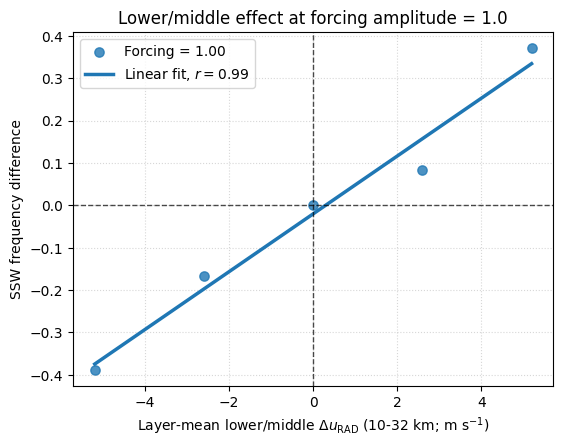

forcing used = 1.0
slope = 0.0683159004403264
intercept = -0.02033999997492895
r = 0.9873047906541806
p = 0.0017138188245171158


In [8]:
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Right panel 1D version: forcing = 1.0
# x = lower/middle Delta uRAD
# y = low/mid SSW frequency difference
# ============================================================

target_forcing = 1.0
i_forcing = np.argmin(np.abs(forcing_values_shear - target_forcing))

x = du_lowmid_mat[i_forcing, :]
y = lowmid_effect_mat[i_forcing, :]

valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]

fit = linregress(x, y)

xfit = np.linspace(np.nanmin(x), np.nanmax(x), 200)
yfit = fit.slope * xfit + fit.intercept

fig, ax = plt.subplots(figsize=(6.2, 4.6))

ax.scatter(
    x,
    y,
    s=45,
    alpha=0.8,
    label=f"Forcing = {forcing_values_shear[i_forcing]:.2f}"
)

ax.plot(
    xfit,
    yfit,
    linewidth=2.5,
    label=fr"Linear fit, $r={fit.rvalue:.2f}$"
)

ax.axhline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
ax.axvline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.7)

ax.set_xlabel(
    rf"Layer-mean lower/middle $\Delta u_{{\mathrm{{RAD}}}}$ "
    rf"({LOWMID_ZMIN:.0f}-{LOWMID_ZMAX:.0f} km; m s$^{{-1}}$)"
)

ax.set_ylabel("SSW frequency difference")
ax.set_title(r"Lower/middle effect at forcing amplitude = 1.0")

ax.grid(True, linestyle=":", alpha=0.5)
ax.legend(fontsize=10)

fig.savefig(
    "lowmid_delta_urad_line_forcing_1p00.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("forcing used =", forcing_values_shear[i_forcing])
print("slope =", fit.slope)
print("intercept =", fit.intercept)
print("r =", fit.rvalue)
print("p =", fit.pvalue)

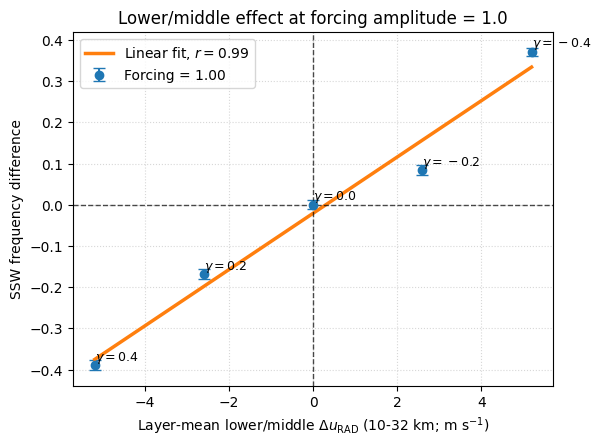

In [9]:
# forcing = 1.0
target_forcing = 1.0
i_forcing = np.argmin(np.abs(forcing_values_shear - target_forcing))

x = du_lowmid_mat[i_forcing, :]
y = lowmid_effect_mat[i_forcing, :]

#  shear_std  nmem
yerr = shear_std[i_forcing, :] / np.sqrt(shear_nmem[i_forcing, :])

valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr)

x = x[valid]
y = y[valid]
yerr = yerr[valid]
gamma_plot = shear_values[valid]

fit = linregress(x, y)

xfit = np.linspace(np.nanmin(x), np.nanmax(x), 200)
yfit = fit.slope * xfit + fit.intercept

fig, ax = plt.subplots(figsize=(6.2, 4.6))

ax.errorbar(
    x, y,
    yerr=yerr,
    fmt="o",
    capsize=4,
    label=f"Forcing = {forcing_values_shear[i_forcing]:.2f}"
)

ax.plot(
    xfit, yfit,
    linewidth=2.5,
    label=fr"Linear fit, $r={fit.rvalue:.2f}$"
)

for xi, yi, gi in zip(x, y, gamma_plot):
    ax.text(
        xi, yi,
        fr"$\gamma={gi:.1f}$",
        fontsize=9,
        ha="left",
        va="bottom"
    )

ax.axhline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
ax.axvline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.7)

ax.set_xlabel(
    rf"Layer-mean lower/middle $\Delta u_{{\mathrm{{RAD}}}}$ "
    rf"({LOWMID_ZMIN:.0f}-{LOWMID_ZMAX:.0f} km; m s$^{{-1}}$)"
)
ax.set_ylabel("SSW frequency difference")
ax.set_title(r"Lower/middle effect at forcing amplitude = 1.0")
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend(fontsize=10)

fig.savefig("lowmid_delta_urad_line_forcing_1p00_errorbar.png", dpi=600, bbox_inches="tight")
plt.show()

DJFM indices in each 160-step season: 39 to 117
Eq. 6 parameters:
  C1_CONST    = 0.0022
  ALPHA_MODEL = 0.5
  U_THRES     = 7
  FLUX_EXTRA  = 16.0
  WT          = 1.0
  H_KM        = 7.0
  FACT_MODE   = exp_minus_z_over_H
  CLIP_NEGATIVE_FZ_TO_ZERO = True
  USE_ABSOLUTE_FZ = False
[INFO] alpha_capacity_scan_Fz_positive_only: param=-0.400, dir=output_sweep_a_n40
  [INFO] forcing=0.50, members=10
    [ens00] Fz/Fzc bounded=0.9178, unbounded=0.6141, Fz=1.7725e-02
    [ens01] Fz/Fzc bounded=0.9193, unbounded=0.6145, Fz=1.7699e-02
    [ens02] Fz/Fzc bounded=0.9120, unbounded=0.6062, Fz=1.7534e-02
    [ens03] Fz/Fzc bounded=0.9084, unbounded=0.6020, Fz=1.7550e-02
    [ens04] Fz/Fzc bounded=0.9128, unbounded=0.6050, Fz=1.7617e-02
    [ens05] Fz/Fzc bounded=0.9184, unbounded=0.6109, Fz=1.7661e-02
    [ens06] Fz/Fzc bounded=0.9117, unbounded=0.6079, Fz=1.7617e-02
    [ens07] Fz/Fzc bounded=0.9101, unbounded=0.6078, Fz=1.7676e-02
    [ens08] Fz/Fzc bounded=0.9119, unbounded=0.6011, Fz=1.7445e-0

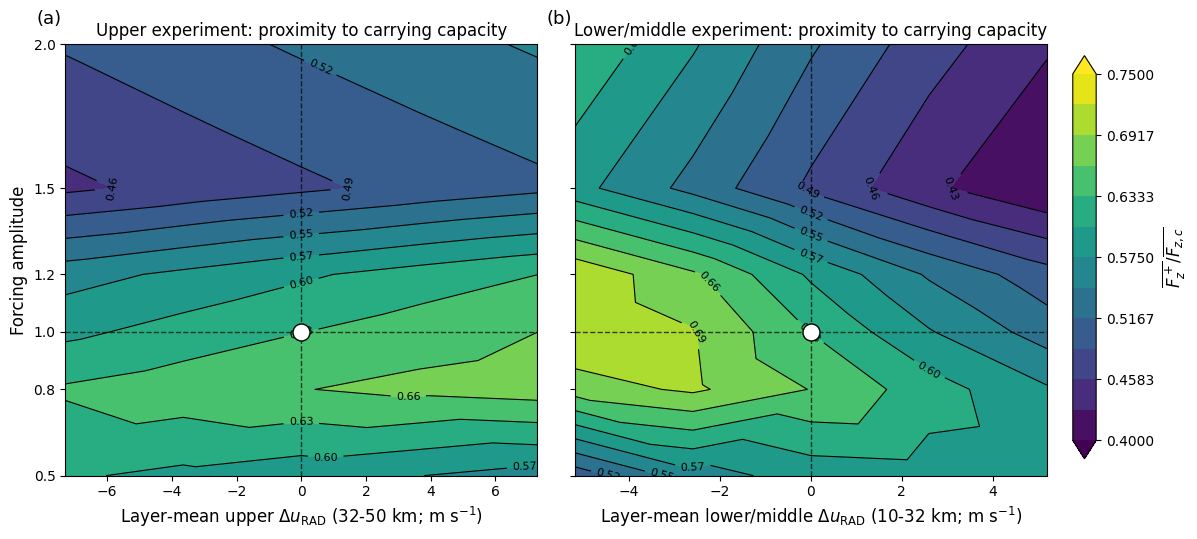

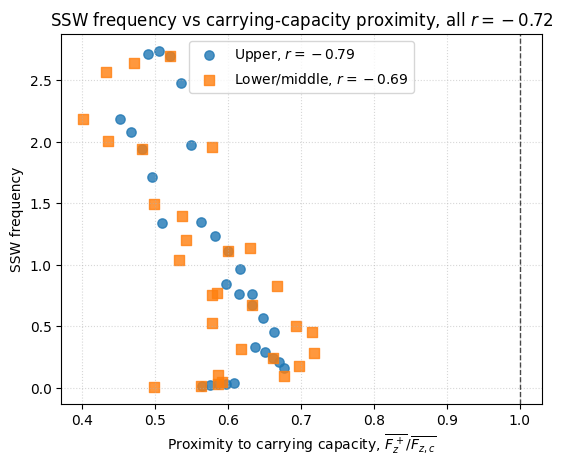

Pearson r, upper = -0.7900
Pearson r, lower/middle = -0.6934
Pearson r, all = -0.7248
Saved numerator/denominator table to: ./ssw_scan_results/carrying_capacity_numerator_denominator_Fz_positive_only.csv
[DONE] Carrying-capacity diagnostic finished.


In [10]:
# %%
"""
Carrying-capacity diagnostic requested by Noboru.

Goal:
For each run in the same parameter space as Fig. 14, compute

    R = <Fz_plus>_DJFM,10hPa / <Fz_c>_DJFM,10hPa

where Fz is reconstructed from Eq. 6, Fz_plus = max(Fz, 0) is the
positive/upward component of Fz, and Fz_c is the maximum Fz allowed by
the same quadratic form. The output figure uses the same coordinates as
the current Fig. 14: layer-mean Delta u_RAD vs forcing amplitude for the
upper and lower/middle experiments.

This script is designed to be appended after, or run after, your current
SSW-frequency scan script. It assumes that these files already exist:

    ./ssw_scan_results/alpha_scan.npz
    ./ssw_scan_results/shear_scan.npz

It reads existing uout/aout/urout files from the Fig. 14 run directories.
No model rerun is needed if those files are already present.
"""

import os
import re
import glob
import csv
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset

# ============================================================
# 0) User settings
# ============================================================

ROOT = "/scratch/smliu01/1d_model"
SAVE_DIR = "./ssw_scan_results"
os.makedirs(SAVE_DIR, exist_ok=True)

URAD_SWEEP_DIR = "/scratch/smliu01/1d_model/urad_parameter_sweep_clean"

ALPHA_SCAN_FILE = os.path.join(SAVE_DIR, "alpha_scan.npz")
SHEAR_SCAN_FILE = os.path.join(SAVE_DIR, "shear_scan.npz")

# Same run-directory structure as your current Fig. 14 script
FORCING_DIRS = [
    "scale_0p50",
    "scale_0p80",
    "scale_1p00",
    "scale_1p20",
    "scale_1p50",
    "scale_2p00",
]

ALPHA_DIR_MAP = {
    "output_sweep_a_n40": -0.4,
    "output_sweep_a_n20": -0.2,
    "output_sweep":        0.0,
    "output_sweep_a_20":   0.2,
    "output_sweep_a_40":   0.4,
}

SHEAR_DIR_MAP = {
    "output_sweep_b_n40": -0.4,
    "output_sweep_b_n20": -0.2,
    "output_sweep_b_00":   0.0,
    "output_sweep_b_20":   0.2,
    "output_sweep_b_40":   0.4,
}

# Model/time settings
YR = 1000
N_PER_YEAR = 160
LEVEL_INDEX_10HPA = 110
DMAX_REF = 992

# DJFM in the original 6-hourly Oct-May calendar.
# Oct 1 -> Dec 1: 61 days * 4 = 244
# Oct 1 -> Apr 1: 182 days * 4 = 728
DJFM_START_STEP_IN_992 = 244
DJFM_END_STEP_IN_992 = 728  # exclusive end, i.e., through March

# Height fallback if height is not saved in uout/aout/urout.
# In your model this is usually z = 10 km + index * 0.2 km,
# so index 110 corresponds to about 32 km, close to 10 hPa.
Z0_KM = 10.0
DZ_KM = 0.2
H_KM = 7.0

# Eq. 6 / Fortran flux parameters.
# IMPORTANT: set these to exactly the values used in the Fig. 14 runs.
# Fortran line:
#   flux = c1 * ( uref - alpha*(p/fact) + flux_extra*S )
#             * ( p - fact*flux_extra*S )
#   S = 1 - 1/(1 + exp(-(ucos-u_thres)/wT))
C1_CONST = 2.2e-3
ALPHA_MODEL = 0.5
U_THRES = 7       # CHANGE to the u_thres used in your runs
FLUX_EXTRA = 16.0    # CHANGE to the flux_extra used in your runs
WT = 1.0             # CHANGE to the wT used in your Fortran code

# fact(k). If fact is not saved in output, this script uses exp(-z/H).
# This is consistent with p=fact*A and flux=c1*fact*(...)*(A-sigma).
FACT_MODE = "exp_minus_z_over_H"

# If your sign convention stores upward EP flux as negative, set this True.
USE_ABSOLUTE_FZ = False

# Noboru's diagnostic is about upward/positive wave-activity flux.
# Rare negative reconstructed Fz spikes can dominate DJFM means, so by default
# use the positive component Fz_plus = max(Fz, 0) for the numerator.
CLIP_NEGATIVE_FZ_TO_ZERO = True

# Variable-name candidates. The script uses the first one found in the file.
UBAR_CANDIDATES = ("ubar", "u", "u_bar", "mean_u")
A_CANDIDATES = ("a", "A", "aa", "aout", "fawa", "FAWA", "wave_activity")
UREF_CANDIDATES = ("urad", "uref", "u_ref", "uREF", "u_rad", "uRAD")
HEIGHT_CANDIDATES = ("height", "z", "lev", "level")

# x-axis coordinate used in the current Fig. 14
UPPER_ZMIN = 32.0
UPPER_ZMAX = 50.0
LOWMID_ZMIN = 10.0
LOWMID_ZMAX = 32.0
URAD_VAR = "urad"
HEIGHT_VAR = "height"

# ============================================================
# 1) Basic helpers
# ============================================================

def parse_scale_name(scale_name):
    return float(scale_name.replace("scale_", "").replace("p", "."))


def list_ensemble_dirs(scale_dir):
    all_subdirs = sorted([
        os.path.join(scale_dir, d)
        for d in os.listdir(scale_dir)
        if os.path.isdir(os.path.join(scale_dir, d))
    ])

    ens_dirs = []
    for d in all_subdirs:
        if re.match(r"ens\d+", os.path.basename(d)):
            ens_dirs.append(d)

    if len(ens_dirs) == 0:
        ens_dirs = all_subdirs

    return sorted(ens_dirs)


def find_nc_file(ens_dir, key):
    """
    Find a netCDF file in ens_dir whose basename contains key.
    Examples: key='uout', 'aout', 'urout'.
    """
    patterns = [
        os.path.join(ens_dir, key + "*.nc"),
        os.path.join(ens_dir, "*" + key + "*.nc"),
    ]

    files = []
    for pat in patterns:
        files.extend(glob.glob(pat))

    files = sorted(set(files))
    if len(files) == 0:
        return None

    # Avoid accidentally selecting budget files if possible.
    exactish = [f for f in files if key in os.path.basename(f)]
    if len(exactish) > 0:
        return exactish[0]

    return files[0]


def first_existing_var(ds, candidates, path):
    for name in candidates:
        if name in ds.variables:
            return name
    raise KeyError(
        "None of the candidate variables were found in {}.\n"
        "Candidates: {}\n"
        "Available variables: {}".format(
            path,
            candidates,
            list(ds.variables.keys())
        )
    )


def read_var_from_file(path, candidates):
    with Dataset(path, "r") as ds:
        name = first_existing_var(ds, candidates, path)
        arr = np.asarray(ds.variables[name][:], dtype=float)
    return arr, name


def read_height_from_file(path):
    with Dataset(path, "r") as ds:
        for name in HEIGHT_CANDIDATES:
            if name in ds.variables:
                return np.asarray(ds.variables[name][:], dtype=float), name
    return None, None


def get_level_height_km(path, level_index):
    height, hname = read_height_from_file(path)
    if height is None:
        return Z0_KM + DZ_KM * level_index

    height = np.squeeze(height)
    if height.ndim != 1 or level_index >= height.size:
        return Z0_KM + DZ_KM * level_index

    return float(height[level_index])


def extract_level_timeseries(arr, level_index, expected_len=None):
    """
    Extract one vertical level and return a flattened time series.

    Expected common shapes:
      (z, time)
      (z, year, time)
      (time,) after extraction
    """
    arr = np.asarray(arr, dtype=float)
    arr = np.squeeze(arr)

    if arr.ndim == 1:
        out = arr
    elif arr.ndim == 2:
        if arr.shape[0] > level_index:
            out = arr[level_index, :]
        elif arr.shape[-1] > level_index:
            out = arr[:, level_index]
        else:
            raise ValueError("Cannot infer vertical dimension for array shape {}".format(arr.shape))
    elif arr.ndim == 3:
        if arr.shape[0] > level_index:
            out = arr[level_index, :, :]
        elif arr.shape[-1] > level_index:
            out = arr[:, :, level_index]
        else:
            raise ValueError("Cannot infer vertical dimension for array shape {}".format(arr.shape))
    else:
        raise ValueError("Unsupported array shape {}".format(arr.shape))

    out = np.asarray(out, dtype=float).reshape(-1)

    if expected_len is not None and out.size != expected_len:
        raise ValueError(
            "Extracted time series length = {}, expected = {}".format(out.size, expected_len)
        )

    return out


def djfm_indices(n_per_year=N_PER_YEAR):
    start = int(np.floor(DJFM_START_STEP_IN_992 / float(DMAX_REF) * n_per_year))
    end = int(np.ceil(DJFM_END_STEP_IN_992 / float(DMAX_REF) * n_per_year))
    start = max(0, min(start, n_per_year))
    end = max(start + 1, min(end, n_per_year))
    return np.arange(start, end, dtype=int)


def djfm_mean_from_flat(x, yr=YR, n_per_year=N_PER_YEAR):
    x = np.asarray(x, dtype=float)
    expected_len = yr * n_per_year
    if x.size != expected_len:
        raise ValueError("Time series length = {}, expected = {}".format(x.size, expected_len))

    x2d = x.reshape(yr, n_per_year)
    idx = djfm_indices(n_per_year)
    return float(np.nanmean(x2d[:, idx]))


def djfm_flat_from_flat(x, yr=YR, n_per_year=N_PER_YEAR):
    x = np.asarray(x, dtype=float)
    expected_len = yr * n_per_year
    if x.size != expected_len:
        raise ValueError("Time series length = {}, expected = {}".format(x.size, expected_len))

    x2d = x.reshape(yr, n_per_year)
    idx = djfm_indices(n_per_year)
    return x2d[:, idx].reshape(-1)

# ============================================================
# 2) Fortran flux: actual Fz and carrying capacity Fz_c
# ============================================================

def stable_exp_arg(x):
    return np.clip(x, -60.0, 60.0)


def sigmoid_switch(ucos):
    """
    S = 1 - 1/(1 + exp(-(ucos-u_thres)/wT))

    This follows the Fortran expression directly:
        1-(1/(1+exp(-(ucos-u_thres)/wT)))
    """
    ucos = np.asarray(ucos, dtype=float)
    arg = stable_exp_arg(-(ucos - U_THRES) / WT)
    return 1.0 - 1.0 / (1.0 + np.exp(arg))


def get_fact_at_level(z_km):
    """
    Reconstruct fact(k) used by the Fortran flux formula.

    If your Fortran defines fact(k) differently, change this function.
    The default assumes fact=exp(-z/H), so that p=fact*A and
        flux = c1*fact*(U+sigma)*(A-sigma).
    """
    if FACT_MODE == "exp_minus_z_over_H":
        return float(np.exp(-z_km / H_KM))
    if FACT_MODE == "one":
        return 1.0
    raise ValueError("Unknown FACT_MODE: {}".format(FACT_MODE))


def compute_fz_actual_fortran(uref, a, ucos, z_km):
    """
    Reconstruct actual Fz using the Fortran expression:

        flux = c1 * ( uref - alpha*(p/fact) + flux_extra*S )
                  * ( p - fact*flux_extra*S )

    Here the saved A is assumed to be p/fact, so p=fact*A.
    ucos is taken from uout/ubar by default.

    By default the numerator uses the positive/upward component

        Fz_plus = max(Fz, 0)

    rather than the raw signed Fz. This prevents rare negative spikes
    from dominating the DJFM mean.
    """
    uref = np.asarray(uref, dtype=float)
    a = np.asarray(a, dtype=float)
    ucos = np.asarray(ucos, dtype=float)

    fact = get_fact_at_level(z_km)
    p = fact * a

    S = sigmoid_switch(ucos)
    sigma = FLUX_EXTRA * S

    # U = uref - alpha*(p/fact) = uref - alpha*A
    base_wind = uref - ALPHA_MODEL * (p / fact)

    fz_raw = C1_CONST * (base_wind + sigma) * (p - fact * sigma)

    if USE_ABSOLUTE_FZ:
        fz = np.abs(fz_raw)
    elif CLIP_NEGATIVE_FZ_TO_ZERO:
        fz = np.where(fz_raw < 0.0, 0.0, fz_raw)
    else:
        fz = fz_raw

    return fz, sigma, S, fact, base_wind


def compute_fz_capacity_fortran(uref, a, z_km, bounded=True):
    """
    Carrying capacity implied by the same Fortran quadratic form.

    For fixed uref and A=p/fact, define
        U = uref - alpha*A.

    The Fortran flux can be written as
        Fz = c1 * fact * (U + sigma) * (A - sigma),
    where sigma = flux_extra*S.

    The unconstrained maximum over sigma is at
        sigma_c = (A - U)/2.

    Since the empirical sigma in the model is bounded by
        0 <= sigma <= flux_extra,
    and the second factor should remain nonnegative,
    the default bounded maximum uses
        0 <= sigma_c <= min(flux_extra, A).
    """
    uref = np.asarray(uref, dtype=float)
    a = np.asarray(a, dtype=float)

    fact = get_fact_at_level(z_km)
    p = fact * a
    base_wind = uref - ALPHA_MODEL * (p / fact)

    sigma_c = 0.5 * (a - base_wind)

    if bounded:
        upper = np.minimum(FLUX_EXTRA, a)
        upper = np.maximum(upper, 0.0)
        sigma_c = np.clip(sigma_c, 0.0, upper)

    fzc = C1_CONST * (base_wind + sigma_c) * (p - fact * sigma_c)

    if USE_ABSOLUTE_FZ:
        fzc = np.abs(fzc)

    fzc = np.where(fzc > 0.0, fzc, np.nan)

    return fzc, sigma_c, fact, base_wind


def compute_member_capacity_diagnostic(ens_dir):
    """
    Compute DJFM, 10-hPa actual Fz, carrying capacity Fz_c, and their ratios
    for one ensemble member directory.
    """
    uout_file = find_nc_file(ens_dir, "uout")
    aout_file = find_nc_file(ens_dir, "aout")
    urout_file = find_nc_file(ens_dir, "urout")

    if uout_file is None:
        raise FileNotFoundError("No uout*.nc file found in {}".format(ens_dir))
    if aout_file is None:
        raise FileNotFoundError("No aout*.nc file found in {}".format(ens_dir))
    if urout_file is None:
        raise FileNotFoundError("No urout*.nc file found in {}".format(ens_dir))

    ubar_raw, u_name = read_var_from_file(uout_file, UBAR_CANDIDATES)
    a_raw, a_name = read_var_from_file(aout_file, A_CANDIDATES)
    uref_raw, uref_name = read_var_from_file(urout_file, UREF_CANDIDATES)

    expected_len = YR * N_PER_YEAR

    # uout is used as ucos in the Fortran sigmoid.
    ucos = extract_level_timeseries(ubar_raw, LEVEL_INDEX_10HPA, expected_len=expected_len)
    a = extract_level_timeseries(a_raw, LEVEL_INDEX_10HPA, expected_len=expected_len)
    uref = extract_level_timeseries(uref_raw, LEVEL_INDEX_10HPA, expected_len=expected_len)

    z_km = get_level_height_km(uout_file, LEVEL_INDEX_10HPA)

    fz, sigma, switch, fact, base_wind = compute_fz_actual_fortran(
        uref=uref,
        a=a,
        ucos=ucos,
        z_km=z_km,
    )

    fzc_unbounded, sigma_c_unbounded, _, _ = compute_fz_capacity_fortran(
        uref=uref,
        a=a,
        z_km=z_km,
        bounded=False,
    )

    fzc_bounded, sigma_c_bounded, _, _ = compute_fz_capacity_fortran(
        uref=uref,
        a=a,
        z_km=z_km,
        bounded=True,
    )

    fz_djfm = djfm_flat_from_flat(fz)
    fzc_unbounded_djfm = djfm_flat_from_flat(fzc_unbounded)
    fzc_bounded_djfm = djfm_flat_from_flat(fzc_bounded)

    # Noboru's wording sounds like ratio of averages.
    fz_mean = float(np.nanmean(fz_djfm))
    fzc_unbounded_mean = float(np.nanmean(fzc_unbounded_djfm))
    fzc_bounded_mean = float(np.nanmean(fzc_bounded_djfm))

    ratio_unbounded = fz_mean / fzc_unbounded_mean if fzc_unbounded_mean > 0 else np.nan
    ratio_bounded = fz_mean / fzc_bounded_mean if fzc_bounded_mean > 0 else np.nan

    # Also save the mean of instantaneous ratios as a sensitivity check.
    mean_ratio_unbounded = float(np.nanmean(fz_djfm / fzc_unbounded_djfm))
    mean_ratio_bounded = float(np.nanmean(fz_djfm / fzc_bounded_djfm))

    return {
        "fz_mean": fz_mean,
        "fzc_unbounded_mean": fzc_unbounded_mean,
        "fzc_bounded_mean": fzc_bounded_mean,
        "ratio_unbounded": ratio_unbounded,
        "ratio_bounded": ratio_bounded,
        "mean_ratio_unbounded": mean_ratio_unbounded,
        "mean_ratio_bounded": mean_ratio_bounded,
        "z_km": z_km,
        "fact": fact,
        "u_variable": u_name,
        "a_variable": a_name,
        "uref_source": uref_name,
    }

# ============================================================
# 3) Scan the Fig. 14 parameter grid
# ============================================================

def scan_capacity_grid(root, param_dir_map, forcing_dirs, scan_name="capacity_scan", verbose=True):
    param_values = sorted(param_dir_map.values())
    forcing_values = np.asarray([parse_scale_name(x) for x in forcing_dirs], dtype=float)

    shape = (len(forcing_values), len(param_values))

    fz_mean_mat = np.full(shape, np.nan)
    fzc_unbounded_mean_mat = np.full(shape, np.nan)
    fzc_bounded_mean_mat = np.full(shape, np.nan)
    ratio_unbounded_mat = np.full(shape, np.nan)
    ratio_bounded_mat = np.full(shape, np.nan)
    mean_ratio_unbounded_mat = np.full(shape, np.nan)
    mean_ratio_bounded_mat = np.full(shape, np.nan)
    nmem_mat = np.zeros(shape, dtype=int)

    value_to_dir = {v: k for k, v in param_dir_map.items()}

    for j, param_value in enumerate(param_values):
        big_dir_name = value_to_dir[param_value]
        big_dir = os.path.join(root, big_dir_name)

        if not os.path.isdir(big_dir):
            print("[WARN] Missing parameter directory: {}".format(big_dir))
            continue

        print("=" * 80)
        print("[INFO] {}: param={:+.3f}, dir={}".format(scan_name, param_value, big_dir_name))

        for i, scale_name in enumerate(forcing_dirs):
            forcing_value = parse_scale_name(scale_name)
            scale_dir = os.path.join(big_dir, scale_name)

            if not os.path.isdir(scale_dir):
                print("  [WARN] Missing forcing directory: {}".format(scale_dir))
                continue

            ens_dirs = list_ensemble_dirs(scale_dir)
            member_results = []

            print("  [INFO] forcing={:.2f}, members={}".format(forcing_value, len(ens_dirs)))

            for ens_dir in ens_dirs:
                ens_name = os.path.basename(ens_dir)
                try:
                    res = compute_member_capacity_diagnostic(ens_dir)
                    member_results.append(res)
                    if verbose:
                        print(
                            "    [{}] Fz/Fzc bounded={:.4f}, unbounded={:.4f}, Fz={:.4e}".format(
                                ens_name,
                                res["ratio_bounded"],
                                res["ratio_unbounded"],
                                res["fz_mean"],
                            )
                        )
                except Exception as e:
                    print("    [ERROR] {}: {}".format(ens_name, e))

            if len(member_results) == 0:
                print("  [WARN] No valid members for forcing={:.2f}, param={:+.3f}".format(
                    forcing_value, param_value
                ))
                continue

            def avg(key):
                return float(np.nanmean([r[key] for r in member_results]))

            fz_mean_mat[i, j] = avg("fz_mean")
            fzc_unbounded_mean_mat[i, j] = avg("fzc_unbounded_mean")
            fzc_bounded_mean_mat[i, j] = avg("fzc_bounded_mean")
            ratio_unbounded_mat[i, j] = avg("ratio_unbounded")
            ratio_bounded_mat[i, j] = avg("ratio_bounded")
            mean_ratio_unbounded_mat[i, j] = avg("mean_ratio_unbounded")
            mean_ratio_bounded_mat[i, j] = avg("mean_ratio_bounded")
            nmem_mat[i, j] = len(member_results)

            print(
                "  [DONE] mean bounded ratio={:.4f}, unbounded ratio={:.4f}, n={}".format(
                    ratio_bounded_mat[i, j],
                    ratio_unbounded_mat[i, j],
                    nmem_mat[i, j]
                )
            )

    save_file = os.path.join(SAVE_DIR, "{}.npz".format(scan_name))
    np.savez(
        save_file,
        param_values=np.asarray(param_values, dtype=float),
        forcing_values=forcing_values,
        fz_mean_mat=fz_mean_mat,
        fzc_unbounded_mean_mat=fzc_unbounded_mean_mat,
        fzc_bounded_mean_mat=fzc_bounded_mean_mat,
        ratio_unbounded_mat=ratio_unbounded_mat,
        ratio_bounded_mat=ratio_bounded_mat,
        mean_ratio_unbounded_mat=mean_ratio_unbounded_mat,
        mean_ratio_bounded_mat=mean_ratio_bounded_mat,
        nmem_mat=nmem_mat,
        C1_CONST=C1_CONST,
        ALPHA_MODEL=ALPHA_MODEL,
        U_THRES=U_THRES,
        FLUX_EXTRA=FLUX_EXTRA,
        WT=WT,
        H_KM=H_KM,
        CLIP_NEGATIVE_FZ_TO_ZERO=CLIP_NEGATIVE_FZ_TO_ZERO,
        USE_ABSOLUTE_FZ=USE_ABSOLUTE_FZ,
        LEVEL_INDEX_10HPA=LEVEL_INDEX_10HPA,
        DJFM_START_STEP_IN_992=DJFM_START_STEP_IN_992,
        DJFM_END_STEP_IN_992=DJFM_END_STEP_IN_992,
    )
    print("\nSaved to: {}".format(save_file))

    return {
        "param_values": np.asarray(param_values, dtype=float),
        "forcing_values": forcing_values,
        "fz_mean_mat": fz_mean_mat,
        "fzc_unbounded_mean_mat": fzc_unbounded_mean_mat,
        "fzc_bounded_mean_mat": fzc_bounded_mean_mat,
        "ratio_unbounded_mat": ratio_unbounded_mat,
        "ratio_bounded_mat": ratio_bounded_mat,
        "mean_ratio_unbounded_mat": mean_ratio_unbounded_mat,
        "mean_ratio_bounded_mat": mean_ratio_bounded_mat,
        "nmem_mat": nmem_mat,
    }

# ============================================================
# 4) Coordinates from current Fig. 14: layer-mean Delta u_RAD
# ============================================================

def load_scan_result(npz_file):
    data = np.load(npz_file)
    return (
        data["param_values"],
        data["forcing_values"],
        data["mean_freq_mat"],
        data["std_freq_mat"],
        data["nmem_mat"],
    )


def format_gamma(gamma):
    if gamma < 0:
        return "m" + f"{abs(gamma):.2f}".replace(".", "p")
    return f"{gamma:.2f}".replace(".", "p")


def read_layermean_urad(path, zmin_km, zmax_km, include_lower=True, include_upper=True):
    with Dataset(path, "r") as ds:
        urad = np.asarray(ds.variables[URAD_VAR][:], dtype=float)
        height = np.asarray(ds.variables[HEIGHT_VAR][:], dtype=float)

    if include_lower:
        mask_low = height >= zmin_km
    else:
        mask_low = height > zmin_km

    if include_upper:
        mask_high = height <= zmax_km
    else:
        mask_high = height < zmax_km

    idx = np.where(mask_low & mask_high)[0]
    if len(idx) == 0:
        raise ValueError("No height levels in {}-{} km for {}".format(zmin_km, zmax_km, path))

    urad_layer = urad[idx, :, :]
    return float(np.nanmean(urad_layer))


def get_sweepA_file(gamma_upper, gamma_lowmid=0.0):
    tag_u = format_gamma(gamma_upper)
    tag_l = format_gamma(gamma_lowmid)
    return os.path.join(URAD_SWEEP_DIR, "urad_sweepA_gU_{}_gL_{}.nc".format(tag_u, tag_l))


def get_sweepB_file(gamma_lowmid, gamma_upper=0.0):
    tag_u = format_gamma(gamma_upper)
    tag_l = format_gamma(gamma_lowmid)
    return os.path.join(URAD_SWEEP_DIR, "urad_sweepB_gU_{}_gL_{}.nc".format(tag_u, tag_l))


def compute_delta_urad_coordinates(alpha_values, forcing_values_alpha, shear_values, forcing_values_shear):
    # Sweep A: upper Delta uRAD
    idx_alpha_ref = np.argmin(np.abs(alpha_values - 0.0))
    urad_upper_abs = np.full((len(forcing_values_alpha), len(alpha_values)), np.nan, dtype=float)

    for j, gamma_upper in enumerate(alpha_values):
        path = get_sweepA_file(gamma_upper, gamma_lowmid=0.0)
        if not os.path.exists(path):
            raise FileNotFoundError(path)
        val = read_layermean_urad(path, UPPER_ZMIN, UPPER_ZMAX, include_lower=True, include_upper=True)
        urad_upper_abs[:, j] = val

    du_upper_mat = urad_upper_abs - urad_upper_abs[:, idx_alpha_ref][:, None]

    # Sweep B: lower/middle Delta uRAD
    idx_shear_ref = np.argmin(np.abs(shear_values - 0.0))
    urad_lowmid_abs = np.full((len(forcing_values_shear), len(shear_values)), np.nan, dtype=float)

    for j, gamma_lowmid in enumerate(shear_values):
        path = get_sweepB_file(gamma_lowmid, gamma_upper=0.0)
        if not os.path.exists(path):
            raise FileNotFoundError(path)
        val = read_layermean_urad(path, LOWMID_ZMIN, LOWMID_ZMAX, include_lower=True, include_upper=False)
        urad_lowmid_abs[:, j] = val

    du_lowmid_mat = urad_lowmid_abs - urad_lowmid_abs[:, idx_shear_ref][:, None]

    return du_upper_mat, du_lowmid_mat

# ============================================================
# 5) Plotting and correlation diagnostics
# ============================================================

def pearson_r(x, y):
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)
    valid = np.isfinite(x) & np.isfinite(y)
    if np.sum(valid) < 2:
        return np.nan
    x = x[valid]
    y = y[valid]
    x = x - np.mean(x)
    y = y - np.mean(y)
    den = np.sqrt(np.sum(x * x) * np.sum(y * y))
    if den == 0:
        return np.nan
    return float(np.sum(x * y) / den)


def plot_capacity_ratio_like_fig14(
    du_upper_mat,
    du_lowmid_mat,
    forcing_values_alpha,
    forcing_values_shear,
    upper_ratio_mat,
    lowmid_ratio_mat,
    ratio_label=r"$\overline{F_z^+}/\overline{F_{z,c}}$",
    cmap="viridis",
    levels=13,
    save_name="para_sweep_Fz_positive_over_capacity.png",
):
    vmin = np.nanmin([np.nanmin(upper_ratio_mat), np.nanmin(lowmid_ratio_mat)])
    vmax = np.nanmax([np.nanmax(upper_ratio_mat), np.nanmax(lowmid_ratio_mat)])

    # If ratios are expected below 1, include 1 on the color scale when possible.
    if np.isfinite(vmin) and np.isfinite(vmax):
        vmax_plot = max(vmax, 0.75)
        vmin_plot = min(vmin, 0.4)
    else:
        vmin_plot, vmax_plot = 0.4, 0.75

    level_values = np.linspace(vmin_plot, vmax_plot, levels)

    Y_upper = np.repeat(forcing_values_alpha[:, None], du_upper_mat.shape[1], axis=1)
    Y_lowmid = np.repeat(forcing_values_shear[:, None], du_lowmid_mat.shape[1], axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), sharey=True)

    # -------------------- upper --------------------
    x1 = du_upper_mat.flatten()
    y1 = Y_upper.flatten()
    z1 = upper_ratio_mat.flatten()
    valid1 = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(z1)

    cf1 = axes[0].tricontourf(
        x1[valid1], y1[valid1], z1[valid1],
        levels=level_values, cmap=cmap, extend="both"
    )
    cs1 = axes[0].tricontour(
        x1[valid1], y1[valid1], z1[valid1],
        levels=level_values, colors="k", linewidths=0.8
    )
    axes[0].clabel(cs1, inline=True, fontsize=8, fmt="%.2f")

    axes[0].axvline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    axes[0].axhline(1, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    axes[0].scatter(0, 1, s=150, facecolor="white", edgecolor="black", linewidth=1.0, zorder=12)

    axes[0].set_xlabel(
        rf"Layer-mean upper $\Delta u_{{\mathrm{{RAD}}}}$ "
        rf"({UPPER_ZMIN:.0f}-{UPPER_ZMAX:.0f} km; m s$^{{-1}}$)",
        fontsize=12,
    )
    axes[0].set_ylabel("Forcing amplitude", fontsize=12)
    axes[0].set_title("Upper experiment: proximity to carrying capacity", fontsize=12)
    axes[0].set_yticks(forcing_values_alpha)
    axes[0].text(-0.06, 1.08, "(a)", transform=axes[0].transAxes, fontsize=13, va="top", ha="left")

    # -------------------- lower/middle --------------------
    x2 = du_lowmid_mat.flatten()
    y2 = Y_lowmid.flatten()
    z2 = lowmid_ratio_mat.flatten()
    valid2 = np.isfinite(x2) & np.isfinite(y2) & np.isfinite(z2)

    cf2 = axes[1].tricontourf(
        x2[valid2], y2[valid2], z2[valid2],
        levels=level_values, cmap=cmap, extend="both"
    )
    cs2 = axes[1].tricontour(
        x2[valid2], y2[valid2], z2[valid2],
        levels=level_values, colors="k", linewidths=0.8
    )
    axes[1].clabel(cs2, inline=True, fontsize=8, fmt="%.2f")

    axes[1].axvline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    axes[1].axhline(1, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    axes[1].scatter(0, 1, s=150, facecolor="white", edgecolor="black", linewidth=1.0, zorder=12)

    axes[1].set_xlabel(
        rf"Layer-mean lower/middle $\Delta u_{{\mathrm{{RAD}}}}$ "
        rf"({LOWMID_ZMIN:.0f}-{LOWMID_ZMAX:.0f} km; m s$^{{-1}}$)",
        fontsize=12,
    )
    axes[1].set_title("Lower/middle experiment: proximity to carrying capacity", fontsize=12)
    axes[1].set_yticks(forcing_values_shear)
    axes[1].text(-0.06, 1.08, "(b)", transform=axes[1].transAxes, fontsize=13, va="top", ha="left")

    fig.subplots_adjust(right=0.88, wspace=0.08)
    cax = fig.add_axes([0.90, 0.14, 0.018, 0.72])
    cbar = fig.colorbar(cf2, cax=cax)
    cbar.set_label(ratio_label, fontsize=12)

    fig.savefig(save_name, dpi=600, bbox_inches="tight")
    plt.show()

    return fig


def plot_ratio_vs_ssw_scatter(
    upper_ratio_mat,
    lowmid_ratio_mat,
    upper_ssw_mat,
    lowmid_ssw_mat,
    save_name="Fz_positive_ratio_vs_ssw_frequency.png",
):
    r_upper = pearson_r(upper_ratio_mat, upper_ssw_mat)
    r_lowmid = pearson_r(lowmid_ratio_mat, lowmid_ssw_mat)
    r_all = pearson_r(
        np.concatenate([upper_ratio_mat.reshape(-1), lowmid_ratio_mat.reshape(-1)]),
        np.concatenate([upper_ssw_mat.reshape(-1), lowmid_ssw_mat.reshape(-1)]),
    )

    fig, ax = plt.subplots(figsize=(6.2, 4.8))

    x1 = upper_ratio_mat.reshape(-1)
    y1 = upper_ssw_mat.reshape(-1)
    valid1 = np.isfinite(x1) & np.isfinite(y1)
    ax.scatter(x1[valid1], y1[valid1], s=45, alpha=0.8, label=fr"Upper, $r={r_upper:.2f}$")

    x2 = lowmid_ratio_mat.reshape(-1)
    y2 = lowmid_ssw_mat.reshape(-1)
    valid2 = np.isfinite(x2) & np.isfinite(y2)
    ax.scatter(x2[valid2], y2[valid2], s=45, alpha=0.8, marker="s", label=fr"Lower/middle, $r={r_lowmid:.2f}$")

    ax.axvline(1.0, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    ax.set_xlabel(r"Proximity to carrying capacity, $\overline{F_z^+}/\overline{F_{z,c}}$")
    ax.set_ylabel("SSW frequency")
    ax.set_title(fr"SSW frequency vs carrying-capacity proximity, all $r={r_all:.2f}$")
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend(fontsize=10)

    fig.savefig(save_name, dpi=600, bbox_inches="tight")
    plt.show()

    print("Pearson r, upper = {:.4f}".format(r_upper))
    print("Pearson r, lower/middle = {:.4f}".format(r_lowmid))
    print("Pearson r, all = {:.4f}".format(r_all))

    return fig


# ============================================================
# 6) Save numerator/denominator table
# ============================================================

def save_capacity_components_csv(alpha_capacity, shear_capacity, save_file):
    """
    Save the numerator, denominator, and ratio for each Fig. 14 grid point.

    The numerator is <Fz_plus> if CLIP_NEGATIVE_FZ_TO_ZERO=True.
    """
    rows = []

    def add_rows(cap, experiment_name, param_label):
        forcing_values = np.asarray(cap["forcing_values"], dtype=float)
        param_values = np.asarray(cap["param_values"], dtype=float)

        for i, forcing in enumerate(forcing_values):
            for j, param in enumerate(param_values):
                rows.append({
                    "experiment": experiment_name,
                    param_label: param,
                    "forcing_amplitude": forcing,
                    "Fz_numerator_mean": cap["fz_mean_mat"][i, j],
                    "Fzc_denominator_bounded_mean": cap["fzc_bounded_mean_mat"][i, j],
                    "Fzc_denominator_unbounded_mean": cap["fzc_unbounded_mean_mat"][i, j],
                    "ratio_bounded": cap["ratio_bounded_mat"][i, j],
                    "ratio_unbounded": cap["ratio_unbounded_mat"][i, j],
                    "mean_instantaneous_ratio_bounded": cap["mean_ratio_bounded_mat"][i, j],
                    "mean_instantaneous_ratio_unbounded": cap["mean_ratio_unbounded_mat"][i, j],
                    "n_members": cap["nmem_mat"][i, j],
                })

    add_rows(alpha_capacity, "upper", "gamma_upper")
    add_rows(shear_capacity, "lower_middle", "gamma_lowmid")

    # Include both gamma columns for a rectangular CSV.
    fieldnames = [
        "experiment",
        "gamma_upper",
        "gamma_lowmid",
        "forcing_amplitude",
        "Fz_numerator_mean",
        "Fzc_denominator_bounded_mean",
        "Fzc_denominator_unbounded_mean",
        "ratio_bounded",
        "ratio_unbounded",
        "mean_instantaneous_ratio_bounded",
        "mean_instantaneous_ratio_unbounded",
        "n_members",
    ]

    with open(save_file, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in rows:
            writer.writerow(row)

    print("Saved numerator/denominator table to: {}".format(save_file))


# ============================================================
# 7) Main run
# ============================================================

if __name__ == "__main__":
    print("DJFM indices in each 160-step season:", djfm_indices(N_PER_YEAR)[0], "to", djfm_indices(N_PER_YEAR)[-1])
    print("Eq. 6 parameters:")
    print("  C1_CONST    =", C1_CONST)
    print("  ALPHA_MODEL =", ALPHA_MODEL)
    print("  U_THRES     =", U_THRES)
    print("  FLUX_EXTRA  =", FLUX_EXTRA)
    print("  WT          =", WT)
    print("  H_KM        =", H_KM)
    print("  FACT_MODE   =", FACT_MODE)
    print("  CLIP_NEGATIVE_FZ_TO_ZERO =", CLIP_NEGATIVE_FZ_TO_ZERO)
    print("  USE_ABSOLUTE_FZ =", USE_ABSOLUTE_FZ)

    # 1) Compute carrying-capacity diagnostics for all runs.
    alpha_capacity = scan_capacity_grid(
        root=ROOT,
        param_dir_map=ALPHA_DIR_MAP,
        forcing_dirs=FORCING_DIRS,
        scan_name="alpha_capacity_scan_Fz_positive_only",
        verbose=True,
    )

    shear_capacity = scan_capacity_grid(
        root=ROOT,
        param_dir_map=SHEAR_DIR_MAP,
        forcing_dirs=FORCING_DIRS,
        scan_name="shear_capacity_scan_Fz_positive_only",
        verbose=True,
    )

    # 2) Load existing SSW frequency matrices from your current script.
    alpha_values, forcing_values_alpha, alpha_mean, alpha_std, alpha_nmem = load_scan_result(ALPHA_SCAN_FILE)
    shear_values, forcing_values_shear, shear_mean, shear_std, shear_nmem = load_scan_result(SHEAR_SCAN_FILE)

    # 3) Compute Fig. 14 x-axis coordinates.
    du_upper_mat, du_lowmid_mat = compute_delta_urad_coordinates(
        alpha_values=alpha_values,
        forcing_values_alpha=forcing_values_alpha,
        shear_values=shear_values,
        forcing_values_shear=forcing_values_shear,
    )

    # 4) Choose which ratio to plot.
    # Noboru described Fz_c as the maximum of the quadratic form and as a
    # function of Uref and A, so the unbounded quadratic maximum is used
    # as the default denominator here.
    upper_ratio_mat = alpha_capacity["ratio_unbounded_mat"]
    lowmid_ratio_mat = shear_capacity["ratio_unbounded_mat"]


    # If you want the model-reachable bounded maximum instead, use these:
    # upper_ratio_mat = alpha_capacity["ratio_bounded_mat"]
    # lowmid_ratio_mat = shear_capacity["ratio_bounded_mat"]

    print("Upper ratio range:", np.nanmin(upper_ratio_mat), np.nanmax(upper_ratio_mat))
    print("Lower/middle ratio range:", np.nanmin(lowmid_ratio_mat), np.nanmax(lowmid_ratio_mat))
    print("Correlation with SSW frequency:")
    print("  upper        r =", pearson_r(upper_ratio_mat, alpha_mean))
    print("  lower/middle r =", pearson_r(lowmid_ratio_mat, shear_mean))

    # 5) Plot ratio in the same coordinate as Fig. 14.
    plot_capacity_ratio_like_fig14(
        du_upper_mat=du_upper_mat,
        du_lowmid_mat=du_lowmid_mat,
        forcing_values_alpha=forcing_values_alpha,
        forcing_values_shear=forcing_values_shear,
        upper_ratio_mat=upper_ratio_mat,
        lowmid_ratio_mat=lowmid_ratio_mat,
        ratio_label=r"$\overline{F_z^+}/\overline{F_{z,c}}$",
        cmap="viridis",
        levels=13,
        save_name="para_sweep_Fz_positive_over_capacity.png",
    )

    # 6) Optional: direct scatter showing positive/negative correlation with SSW frequency.
    plot_ratio_vs_ssw_scatter(
        upper_ratio_mat=upper_ratio_mat,
        lowmid_ratio_mat=lowmid_ratio_mat,
        upper_ssw_mat=alpha_mean,
        lowmid_ssw_mat=shear_mean,
        save_name="Fz_positive_ratio_vs_ssw_frequency.png",
    )

    save_capacity_components_csv(
        alpha_capacity=alpha_capacity,
        shear_capacity=shear_capacity,
        save_file=os.path.join(SAVE_DIR, "carrying_capacity_numerator_denominator_Fz_positive_only.csv"),
    )

    print("[DONE] Carrying-capacity diagnostic finished.")


In [11]:
def plot_capacity_ratio_like_fig14(
    du_upper_mat,
    du_lowmid_mat,
    forcing_values_alpha,
    forcing_values_shear,
    upper_ratio_mat,
    lowmid_ratio_mat,
    ratio_label=r"$\overline{F_z^+}/\overline{F_{z,c}}$",
    cmap="viridis",
    levels=13,
    save_name="para_sweep_Fz_positive_over_capacity.png",
):
    vmin = np.nanmin([np.nanmin(upper_ratio_mat), np.nanmin(lowmid_ratio_mat)])
    vmax = np.nanmax([np.nanmax(upper_ratio_mat), np.nanmax(lowmid_ratio_mat)])

    # If ratios are expected below 1, include 1 on the color scale when possible.
    if np.isfinite(vmin) and np.isfinite(vmax):
        vmax_plot = max(vmax, 0.75)
        vmin_plot = min(vmin, 0.4)
    else:
        vmin_plot, vmax_plot = 0.4, 0.75

    level_values = np.linspace(vmin_plot, vmax_plot, levels)

    Y_upper = np.repeat(forcing_values_alpha[:, None], du_upper_mat.shape[1], axis=1)
    Y_lowmid = np.repeat(forcing_values_shear[:, None], du_lowmid_mat.shape[1], axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), sharey=True)

    # -------------------- upper --------------------
    x1 = du_upper_mat.flatten()
    y1 = Y_upper.flatten()
    z1 = upper_ratio_mat.flatten()
    valid1 = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(z1)

    cf1 = axes[0].tricontourf(
        x1[valid1], y1[valid1], z1[valid1],
        levels=level_values, cmap=cmap, extend="both"
    )
    cs1 = axes[0].tricontour(
        x1[valid1], y1[valid1], z1[valid1],
        levels=level_values, colors="k", linewidths=0.8
    )
    axes[0].clabel(cs1, inline=True, fontsize=8, fmt="%.2f")

    axes[0].axvline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    axes[0].axhline(1, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    axes[0].scatter(0, 1, s=150, facecolor="white", edgecolor="black", linewidth=1.0, zorder=12)

    axes[0].set_xlabel(
        rf"Layer-mean upper $\Delta u_{{\mathrm{{RAD}}}}$ "
        rf"({UPPER_ZMIN:.0f}-{UPPER_ZMAX:.0f} km; m s$^{{-1}}$)",
        fontsize=12,
    )
    axes[0].set_ylabel("Forcing amplitude", fontsize=12)
    axes[0].set_title("Upper experiment: proximity to carrying capacity", fontsize=12)
    axes[0].set_yticks(forcing_values_alpha)
    axes[0].text(-0.06, 1.08, "(a)", transform=axes[0].transAxes, fontsize=13, va="top", ha="left")

    # -------------------- lower/middle --------------------
    x2 = du_lowmid_mat.flatten()
    y2 = Y_lowmid.flatten()
    z2 = lowmid_ratio_mat.flatten()
    valid2 = np.isfinite(x2) & np.isfinite(y2) & np.isfinite(z2)

    cf2 = axes[1].tricontourf(
        x2[valid2], y2[valid2], z2[valid2],
        levels=level_values, cmap=cmap, extend="both"
    )
    cs2 = axes[1].tricontour(
        x2[valid2], y2[valid2], z2[valid2],
        levels=level_values, colors="k", linewidths=0.8
    )
    axes[1].clabel(cs2, inline=True, fontsize=8, fmt="%.2f")

    axes[1].axvline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    axes[1].axhline(1, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    axes[1].scatter(0, 1, s=150, facecolor="white", edgecolor="black", linewidth=1.0, zorder=12)

    axes[1].set_xlabel(
        rf"Layer-mean lower/middle $\Delta u_{{\mathrm{{RAD}}}}$ "
        rf"({LOWMID_ZMIN:.0f}-{LOWMID_ZMAX:.0f} km; m s$^{{-1}}$)",
        fontsize=12,
    )
    axes[1].set_title("Lower/middle experiment: proximity to carrying capacity", fontsize=12)
    axes[1].set_yticks(forcing_values_shear)
    axes[1].text(-0.06, 1.08, "(b)", transform=axes[1].transAxes, fontsize=13, va="top", ha="left")

    fig.subplots_adjust(right=0.88, wspace=0.08)
    cax = fig.add_axes([0.90, 0.14, 0.018, 0.72])
    cbar = fig.colorbar(cf2, cax=cax)
    cbar.set_label(ratio_label, fontsize=12)

    fig.savefig(save_name, dpi=600, bbox_inches="tight")
    plt.show()

    return fig

Bounded ratio range:
Upper: 0.4524607398195908 0.6767939962246703
Lower/middle: 0.4012910541999949 0.7174581821342615
Correlation with SSW frequency:
  upper        r = -0.7899853909113574
  lower/middle r = -0.6933662434360026
  all          r = -0.7248389626386151


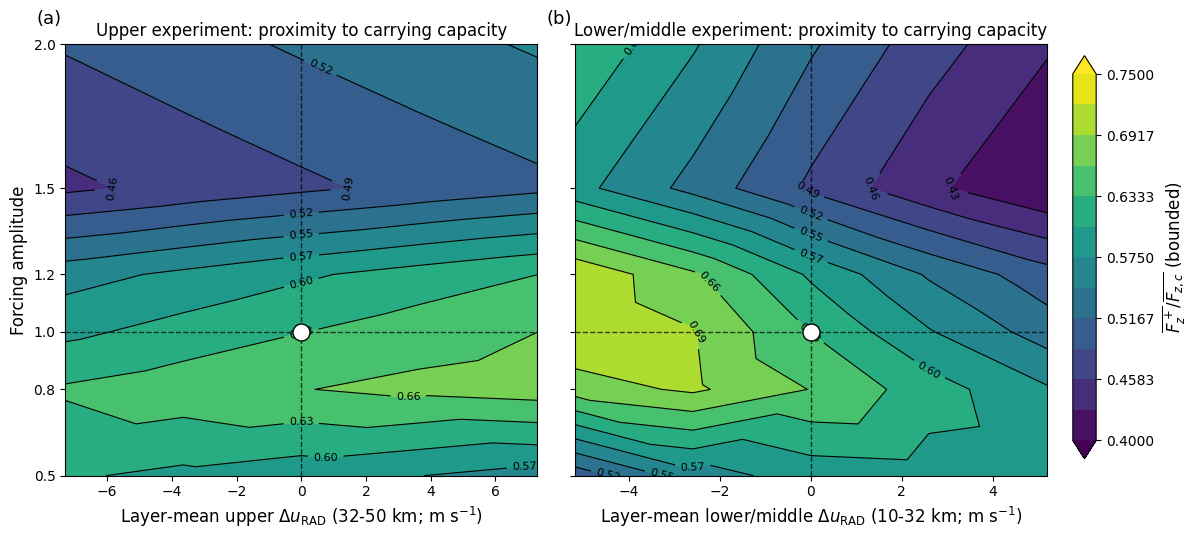

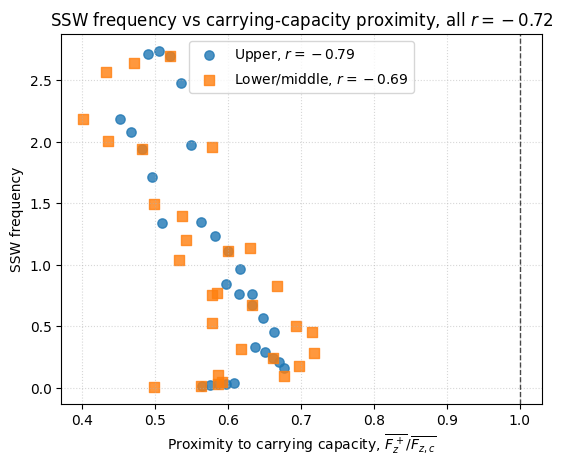

Pearson r, upper = -0.7900
Pearson r, lower/middle = -0.6934
Pearson r, all = -0.7248


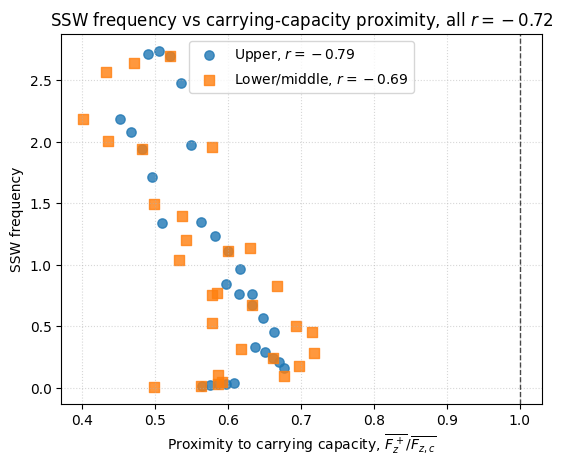

In [12]:
# %%
# ============================================================
# Plot bounded Fz/Fzc ratio without re-scanning
# ============================================================

# Use existing variables from the main script
upper_ratio_bounded = alpha_capacity["ratio_unbounded_mat"]
lowmid_ratio_bounded = shear_capacity["ratio_unbounded_mat"]

print("Bounded ratio range:")
print("Upper:", np.nanmin(upper_ratio_bounded), np.nanmax(upper_ratio_bounded))
print("Lower/middle:", np.nanmin(lowmid_ratio_bounded), np.nanmax(lowmid_ratio_bounded))

print("Correlation with SSW frequency:")
print("  upper        r =", pearson_r(upper_ratio_bounded, alpha_mean))
print("  lower/middle r =", pearson_r(lowmid_ratio_bounded, shear_mean))
print("  all          r =", pearson_r(
    np.concatenate([upper_ratio_bounded.reshape(-1), lowmid_ratio_bounded.reshape(-1)]),
    np.concatenate([alpha_mean.reshape(-1), shear_mean.reshape(-1)])
))

plot_capacity_ratio_like_fig14(
    du_upper_mat=du_upper_mat,
    du_lowmid_mat=du_lowmid_mat,
    forcing_values_alpha=forcing_values_alpha,
    forcing_values_shear=forcing_values_shear,
    upper_ratio_mat=upper_ratio_bounded,
    lowmid_ratio_mat=lowmid_ratio_bounded,
    ratio_label=r"$\overline{F_z^+}/\overline{F_{z,c}}$ (bounded)",
    cmap="viridis",
    levels=13,
    save_name="para_sweep_Fz_positive_over_capacity_bounded.png",
)

plot_ratio_vs_ssw_scatter(
    upper_ratio_mat=upper_ratio_bounded,
    lowmid_ratio_mat=lowmid_ratio_bounded,
    upper_ssw_mat=alpha_mean,
    lowmid_ssw_mat=shear_mean,
    save_name="Fz_positive_ratio_vs_ssw_frequency_bounded.png",
)

In [13]:
upper_ratio_bounded

array([[0.60763742, 0.59760975, 0.58683412, 0.57546659, 0.56378843],
       [0.63711267, 0.65046766, 0.66147227, 0.67023859, 0.676794  ],
       [0.59729909, 0.61548577, 0.63264381, 0.64829311, 0.66240007],
       [0.56271215, 0.5813887 , 0.5994675 , 0.61679222, 0.63311331],
       [0.45246074, 0.46703926, 0.48176008, 0.49607201, 0.50997101],
       [0.49032208, 0.50565705, 0.52064333, 0.53527754, 0.5493325 ]])

In [14]:
# %%
# Correlation restricted to forcing amplitude 0.8--1.5

def subset_correlation_by_forcing(ratio_mat, ssw_mat, forcing_values, fmin=0.8, fmax=1.5):
    forcing_values = np.asarray(forcing_values, dtype=float)
    mask = (forcing_values >= fmin) & (forcing_values <= fmax)

    ratio_sub = ratio_mat[mask, :]
    ssw_sub = ssw_mat[mask, :]

    r = pearson_r(ratio_sub, ssw_sub)

    print(f"Forcing range = [{fmin}, {fmax}]")
    print("Selected forcing values:", forcing_values[mask])
    print("Subset correlation r =", r)

    return r, ratio_sub, ssw_sub, mask


print("Upper experiment:")
r_upper_mid, upper_ratio_sub, upper_ssw_sub, mask_upper = subset_correlation_by_forcing(
    upper_ratio_bounded, alpha_mean, forcing_values_alpha, fmin=0.8, fmax=1.5
)

print("\nLower/middle experiment:")
r_lowmid_mid, lowmid_ratio_sub, lowmid_ssw_sub, mask_lowmid = subset_correlation_by_forcing(
    lowmid_ratio_bounded, shear_mean, forcing_values_shear, fmin=0.8, fmax=1.5
)

print("\nCombined:")
r_all_mid = pearson_r(
    np.concatenate([upper_ratio_sub.reshape(-1), lowmid_ratio_sub.reshape(-1)]),
    np.concatenate([upper_ssw_sub.reshape(-1), lowmid_ssw_sub.reshape(-1)])
)
print("Combined subset correlation r =", r_all_mid)

Upper experiment:
Forcing range = [0.8, 1.5]
Selected forcing values: [0.8 1.  1.2 1.5]
Subset correlation r = -0.9726293871874372

Lower/middle experiment:
Forcing range = [0.8, 1.5]
Selected forcing values: [0.8 1.  1.2 1.5]
Subset correlation r = -0.9150550097142622

Combined:
Combined subset correlation r = -0.9318104376939161


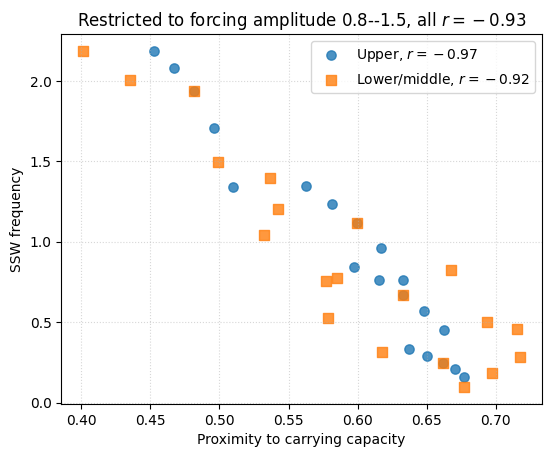

In [15]:
# %%
fig, ax = plt.subplots(figsize=(6.2, 4.8))

x1 = upper_ratio_sub.reshape(-1)
y1 = upper_ssw_sub.reshape(-1)
valid1 = np.isfinite(x1) & np.isfinite(y1)
ax.scatter(x1[valid1], y1[valid1], s=45, alpha=0.8, label=fr"Upper, $r={r_upper_mid:.2f}$")

x2 = lowmid_ratio_sub.reshape(-1)
y2 = lowmid_ssw_sub.reshape(-1)
valid2 = np.isfinite(x2) & np.isfinite(y2)
ax.scatter(x2[valid2], y2[valid2], s=45, alpha=0.8, marker="s", label=fr"Lower/middle, $r={r_lowmid_mid:.2f}$")

ax.set_xlabel(r"Proximity to carrying capacity")
ax.set_ylabel("SSW frequency")
ax.set_title(fr"Restricted to forcing amplitude 0.8--1.5, all $r={r_all_mid:.2f}$")
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend(fontsize=10)

plt.show()

Pre-onset window:
  days before onset: 10.0 to 5.0
  steps_per_day on 160-step grid: 0.6451612903225806
  approximate step window: 6 to 3
[INFO] alpha_preonset_10to5d_capacity: param=-0.400, dir=output_sweep_a_n40
  [INFO] forcing=0.50, members=10


    [ens00] n_ssw=45, n_used=45
    [ens01] n_ssw=58, n_used=58
    [ens02] n_ssw=59, n_used=59
    [ens03] n_ssw=86, n_used=86
    [ens04] n_ssw=56, n_used=56
    [ens05] n_ssw=63, n_used=63
    [ens06] n_ssw=53, n_used=53
    [ens07] n_ssw=58, n_used=58
    [ens08] n_ssw=62, n_used=62
    [ens09] n_ssw=61, n_used=61
  [DONE] n_events=601, ratio bounded=0.8133, unbounded=0.6801
  [INFO] forcing=0.80, members=10
    [ens00] n_ssw=350, n_used=350
    [ens01] n_ssw=369, n_used=368
    [ens02] n_ssw=357, n_used=357
    [ens03] n_ssw=402, n_used=401
    [ens04] n_ssw=168, n_used=168
    [ens05] n_ssw=333, n_used=333
    [ens06] n_ssw=364, n_used=364
    [ens07] n_ssw=378, n_used=378
    [ens08] n_ssw=328, n_used=327
    [ens09] n_ssw=370, n_used=370
  [DONE] n_events=3416, ratio bounded=0.7186, unbounded=0.6180
  [INFO] forcing=1.00, members=10
    [ens00] n_ssw=772, n_used=769
    [ens01] n_ssw=776, n_used=773
    [ens02] n_ssw=715, n_used=715
    [ens03] n_ssw=810, n_used=810
    [ens04]

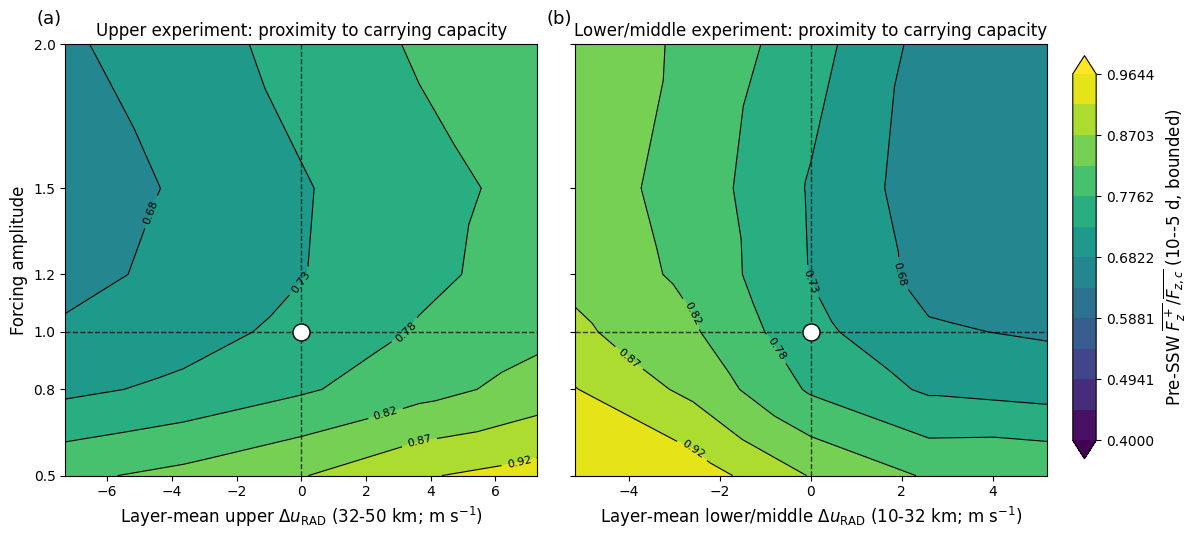

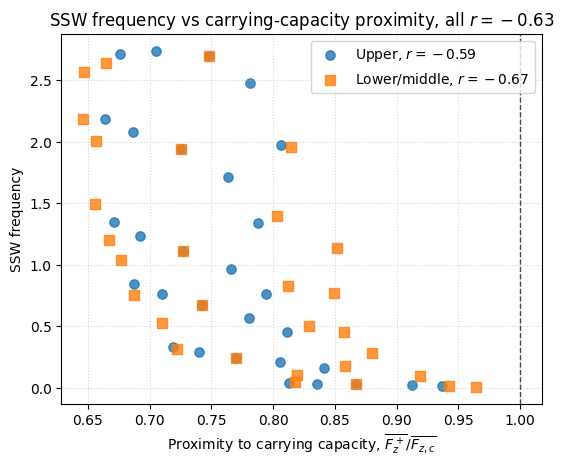

Pearson r, upper = -0.5931
Pearson r, lower/middle = -0.6694
Pearson r, all = -0.6266
[DONE] Pre-SSW-onset carrying-capacity composite finished.


In [16]:
# %%
# ============================================================
# Pre-SSW-onset carrying-capacity composite
# Window: 10 to 5 days before each SSW onset
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Settings
# ------------------------------------------------------------

PRE_ONSET_START_DAYS = 10.0   # farther from onset
PRE_ONSET_END_DAYS   = 5.0    # closer to onset

# Use positive/upward flux only, consistent with previous diagnostic
USE_POSITIVE_FZ_PREONSET = True

# Choose carrying-capacity definition for the plot:
#   "bounded"   : sigma_c constrained to model-allowed range
#   "unbounded" : pure quadratic maximum, function of uref and A
FZC_CHOICE_PREONSET = "bounded"

# SSW detection settings, same as your SSW-frequency calculation
MIN_GAP_DAYS = 10.0
MIN_GAP_ONSET_DAYS = 20.0
MIN_DURATION_DAYS = 2.0
ENFORCE_MARCH10 = True
MARCH10_STEP_IN_992 = 640


# ------------------------------------------------------------
# 1. SSW detection function
# ------------------------------------------------------------

def count_ssw_events_ubar_2d(
    u_2d,
    dmax_ref=992,
    min_gap_days=10.0,
    min_gap_onset_days=20.0,
    min_duration_days=2.0,
    enforce_march10_cutoff=True,
    march10_step_in_992=640,
    return_debug=False,
):
    """
    Detect SSW events from ubar<0 continuous segments.
    Returns flat-index event onset/end pairs.
    """
    u_2d = np.asarray(u_2d, float)
    years, n_per_year = u_2d.shape

    steps_per_day = 4.0 * (n_per_year / float(dmax_ref))

    min_gap_steps       = max(1, int(round(min_gap_days * steps_per_day)))
    min_gap_onset_steps = max(1, int(round(min_gap_onset_days * steps_per_day)))
    min_dur_steps       = max(1, int(round(min_duration_days * steps_per_day)))

    cutoff_step = int(round(march10_step_in_992 / float(dmax_ref) * n_per_year))

    neg = (u_2d < 0.0)
    neg_flat = neg.ravel()
    T = neg_flat.size

    onsets = []
    ends = []

    if T == 0:
        return (0, [], {}) if return_debug else (0, [])

    if neg_flat[0]:
        onsets.append(0)

    for t in range(1, T):
        if neg_flat[t] and not neg_flat[t - 1]:
            onsets.append(t)
        if (not neg_flat[t]) and neg_flat[t - 1]:
            ends.append(t - 1)

    if neg_flat[-1]:
        ends.append(T - 1)

    m = min(len(onsets), len(ends))
    onsets = onsets[:m]
    ends = ends[:m]

    raw_events = [(s, e) for s, e in zip(onsets, ends) if e > s]

    filtered = []
    for s, e in raw_events:
        if (e - s + 1) < min_dur_steps:
            continue
        if ((e + 1) % n_per_year) == 0:
            continue
        filtered.append((s, e))

    final_events = []
    for s, e in filtered:
        if not final_events:
            final_events.append((s, e))
            continue

        s_prev, e_prev = final_events[-1]
        ok_gap_prev_end = (s - e_prev) >= min_gap_steps
        ok_gap_prev_onset = (s - s_prev) >= min_gap_onset_steps

        ok_gap_prev2_end = True
        if len(final_events) >= 2:
            s_prev2, e_prev2 = final_events[-2]
            ok_gap_prev2_end = (s - e_prev2) >= min_gap_steps

        if ok_gap_prev_end and ok_gap_prev2_end and ok_gap_prev_onset:
            final_events.append((s, e))

    if enforce_march10_cutoff:
        kept = []
        for s, e in final_events:
            j = s % n_per_year
            if j > cutoff_step:
                continue
            kept.append((s, e))
        final_events = kept

    n_ssw = len(final_events)

    debug = dict(
        steps_per_day=steps_per_day,
        min_gap_steps=min_gap_steps,
        min_gap_onset_steps=min_gap_onset_steps,
        min_dur_steps=min_dur_steps,
        cutoff_step=cutoff_step,
        raw_events=raw_events,
        filtered_events=filtered,
        final_events=final_events,
    )

    return (n_ssw, final_events, debug) if return_debug else (n_ssw, final_events)


# ------------------------------------------------------------
# 2. Helper: get pre-onset window indices
# ------------------------------------------------------------

def pre_onset_window_indices(
    onset_flat_index,
    n_per_year=N_PER_YEAR,
    dmax_ref=DMAX_REF,
    pre_start_days=PRE_ONSET_START_DAYS,
    pre_end_days=PRE_ONSET_END_DAYS,
):
    """
    Return flat indices for the window from onset-pre_start_days
    to onset-pre_end_days.

    Example: pre_start_days=10, pre_end_days=5 means 10--5 days before onset.
    """
    steps_per_day = 4.0 * (n_per_year / float(dmax_ref))

    pre_start_steps = int(round(pre_start_days * steps_per_day))
    pre_end_steps = int(round(pre_end_days * steps_per_day))

    pre_start_steps = max(pre_start_steps, 1)
    pre_end_steps = max(pre_end_steps, 0)

    # Ensure the farther-before-onset edge is farther than the near edge
    if pre_start_steps <= pre_end_steps:
        pre_start_steps = pre_end_steps + 1

    year = onset_flat_index // n_per_year
    j_onset = onset_flat_index % n_per_year

    j0 = j_onset - pre_start_steps
    j1 = j_onset - pre_end_steps + 1   # inclusive end converted to exclusive

    # Do not let a pre-onset composite cross the season boundary
    if j0 < 0 or j1 <= j0:
        return np.array([], dtype=int)

    local_idx = np.arange(j0, j1, dtype=int)
    flat_idx = year * n_per_year + local_idx

    return flat_idx


# ------------------------------------------------------------
# 3. Member-level pre-onset composite
# ------------------------------------------------------------

def compute_member_preonset_capacity_diagnostic(ens_dir):
    """
    For one ensemble member:
    1. detect SSW onsets from 10-hPa ubar;
    2. compute Fz and Fzc at 10 hPa;
    3. average Fz and Fzc over the 10--5 day pre-onset window for each event.
    """
    uout_file = find_nc_file(ens_dir, "uout")
    aout_file = find_nc_file(ens_dir, "aout")
    urout_file = find_nc_file(ens_dir, "urout")

    if uout_file is None:
        raise FileNotFoundError("No uout*.nc file found in {}".format(ens_dir))
    if aout_file is None:
        raise FileNotFoundError("No aout*.nc file found in {}".format(ens_dir))
    if urout_file is None:
        raise FileNotFoundError("No urout*.nc file found in {}".format(ens_dir))

    ubar_raw, u_name = read_var_from_file(uout_file, UBAR_CANDIDATES)
    a_raw, a_name = read_var_from_file(aout_file, A_CANDIDATES)
    uref_raw, uref_name = read_var_from_file(urout_file, UREF_CANDIDATES)

    expected_len = YR * N_PER_YEAR

    ucos = extract_level_timeseries(
        ubar_raw,
        LEVEL_INDEX_10HPA,
        expected_len=expected_len,
    )

    a = extract_level_timeseries(
        a_raw,
        LEVEL_INDEX_10HPA,
        expected_len=expected_len,
    )

    uref = extract_level_timeseries(
        uref_raw,
        LEVEL_INDEX_10HPA,
        expected_len=expected_len,
    )

    z_km = get_level_height_km(uout_file, LEVEL_INDEX_10HPA)

    # Reconstruct actual Fz
    fz, sigma, switch, fact, base_wind = compute_fz_actual_fortran(
        uref=uref,
        a=a,
        ucos=ucos,
        z_km=z_km,
    )

    if USE_POSITIVE_FZ_PREONSET:
        fz = np.where(fz < 0.0, 0.0, fz)

    # Carrying capacity
    fzc_unbounded, sigma_c_unbounded, _, _ = compute_fz_capacity_fortran(
        uref=uref,
        a=a,
        z_km=z_km,
        bounded=False,
    )

    fzc_bounded, sigma_c_bounded, _, _ = compute_fz_capacity_fortran(
        uref=uref,
        a=a,
        z_km=z_km,
        bounded=True,
    )

    # Detect SSW events from 10-hPa ubar/ucos
    u2d = ucos.reshape(YR, N_PER_YEAR)

    n_ssw, events = count_ssw_events_ubar_2d(
        u2d,
        dmax_ref=DMAX_REF,
        min_gap_days=MIN_GAP_DAYS,
        min_gap_onset_days=MIN_GAP_ONSET_DAYS,
        min_duration_days=MIN_DURATION_DAYS,
        enforce_march10_cutoff=ENFORCE_MARCH10,
        march10_step_in_992=MARCH10_STEP_IN_992,
        return_debug=False,
    )

    event_fz = []
    event_fzc_unbounded = []
    event_fzc_bounded = []
    event_onsets = []

    for s, e in events:
        idx = pre_onset_window_indices(
            onset_flat_index=s,
            n_per_year=N_PER_YEAR,
            dmax_ref=DMAX_REF,
            pre_start_days=PRE_ONSET_START_DAYS,
            pre_end_days=PRE_ONSET_END_DAYS,
        )

        if idx.size == 0:
            continue

        this_fz = float(np.nanmean(fz[idx]))
        this_fzc_unbounded = float(np.nanmean(fzc_unbounded[idx]))
        this_fzc_bounded = float(np.nanmean(fzc_bounded[idx]))

        if not np.isfinite(this_fz):
            continue

        event_fz.append(this_fz)
        event_fzc_unbounded.append(this_fzc_unbounded)
        event_fzc_bounded.append(this_fzc_bounded)
        event_onsets.append(s)

    event_fz = np.asarray(event_fz, dtype=float)
    event_fzc_unbounded = np.asarray(event_fzc_unbounded, dtype=float)
    event_fzc_bounded = np.asarray(event_fzc_bounded, dtype=float)
    event_onsets = np.asarray(event_onsets, dtype=int)

    return {
        "event_fz": event_fz,
        "event_fzc_unbounded": event_fzc_unbounded,
        "event_fzc_bounded": event_fzc_bounded,
        "event_onsets": event_onsets,
        "n_ssw_detected": n_ssw,
        "n_events_used": event_fz.size,
        "z_km": z_km,
        "fact": fact,
        "u_variable": u_name,
        "a_variable": a_name,
        "uref_source": uref_name,
    }


# ------------------------------------------------------------
# 4. Grid scan: event-pooled pre-onset composite
# ------------------------------------------------------------

def scan_preonset_capacity_grid(
    root,
    param_dir_map,
    forcing_dirs,
    scan_name="preonset_capacity_scan",
    verbose=True,
):
    param_values = sorted(param_dir_map.values())
    forcing_values = np.asarray([parse_scale_name(x) for x in forcing_dirs], dtype=float)

    shape = (len(forcing_values), len(param_values))

    fz_mean_mat = np.full(shape, np.nan)
    fzc_unbounded_mean_mat = np.full(shape, np.nan)
    fzc_bounded_mean_mat = np.full(shape, np.nan)

    ratio_unbounded_mat = np.full(shape, np.nan)
    ratio_bounded_mat = np.full(shape, np.nan)

    mean_event_ratio_unbounded_mat = np.full(shape, np.nan)
    mean_event_ratio_bounded_mat = np.full(shape, np.nan)

    n_events_mat = np.zeros(shape, dtype=int)
    nmem_mat = np.zeros(shape, dtype=int)

    value_to_dir = {v: k for k, v in param_dir_map.items()}

    for j, param_value in enumerate(param_values):
        big_dir_name = value_to_dir[param_value]
        big_dir = os.path.join(root, big_dir_name)

        if not os.path.isdir(big_dir):
            print("[WARN] Missing parameter directory:", big_dir)
            continue

        print("=" * 80)
        print("[INFO] {}: param={:+.3f}, dir={}".format(
            scan_name, param_value, big_dir_name
        ))

        for i, scale_name in enumerate(forcing_dirs):
            forcing_value = parse_scale_name(scale_name)
            scale_dir = os.path.join(big_dir, scale_name)

            if not os.path.isdir(scale_dir):
                print("  [WARN] Missing forcing directory:", scale_dir)
                continue

            ens_dirs = list_ensemble_dirs(scale_dir)

            all_event_fz = []
            all_event_fzc_unbounded = []
            all_event_fzc_bounded = []
            valid_members = 0

            print("  [INFO] forcing={:.2f}, members={}".format(
                forcing_value, len(ens_dirs)
            ))

            for ens_dir in ens_dirs:
                ens_name = os.path.basename(ens_dir)

                try:
                    res = compute_member_preonset_capacity_diagnostic(ens_dir)
                    valid_members += 1

                    if res["n_events_used"] > 0:
                        all_event_fz.append(res["event_fz"])
                        all_event_fzc_unbounded.append(res["event_fzc_unbounded"])
                        all_event_fzc_bounded.append(res["event_fzc_bounded"])

                    if verbose:
                        print(
                            "    [{}] n_ssw={}, n_used={}".format(
                                ens_name,
                                res["n_ssw_detected"],
                                res["n_events_used"],
                            )
                        )

                except Exception as e:
                    print("    [ERROR] {}: {}".format(ens_name, e))

            nmem_mat[i, j] = valid_members

            if len(all_event_fz) == 0:
                print("  [WARN] No SSW events available for pre-onset composite.")
                continue

            all_event_fz = np.concatenate(all_event_fz)
            all_event_fzc_unbounded = np.concatenate(all_event_fzc_unbounded)
            all_event_fzc_bounded = np.concatenate(all_event_fzc_bounded)

            valid_unbounded = (
                np.isfinite(all_event_fz)
                & np.isfinite(all_event_fzc_unbounded)
                & (all_event_fzc_unbounded > 0)
            )

            valid_bounded = (
                np.isfinite(all_event_fz)
                & np.isfinite(all_event_fzc_bounded)
                & (all_event_fzc_bounded > 0)
            )

            n_events_mat[i, j] = int(np.sum(valid_bounded | valid_unbounded))

            if np.sum(valid_unbounded) > 0:
                fz_mean_u = float(np.nanmean(all_event_fz[valid_unbounded]))
                fzc_mean_u = float(np.nanmean(all_event_fzc_unbounded[valid_unbounded]))

                fz_mean_mat[i, j] = fz_mean_u
                fzc_unbounded_mean_mat[i, j] = fzc_mean_u
                ratio_unbounded_mat[i, j] = fz_mean_u / fzc_mean_u

                mean_event_ratio_unbounded_mat[i, j] = float(
                    np.nanmean(
                        all_event_fz[valid_unbounded]
                        / all_event_fzc_unbounded[valid_unbounded]
                    )
                )

            if np.sum(valid_bounded) > 0:
                fz_mean_b = float(np.nanmean(all_event_fz[valid_bounded]))
                fzc_mean_b = float(np.nanmean(all_event_fzc_bounded[valid_bounded]))

                # Keep fz_mean_mat as event-mean Fz; same numerator for both definitions
                fz_mean_mat[i, j] = fz_mean_b
                fzc_bounded_mean_mat[i, j] = fzc_mean_b
                ratio_bounded_mat[i, j] = fz_mean_b / fzc_mean_b

                mean_event_ratio_bounded_mat[i, j] = float(
                    np.nanmean(
                        all_event_fz[valid_bounded]
                        / all_event_fzc_bounded[valid_bounded]
                    )
                )

            print(
                "  [DONE] n_events={}, ratio bounded={:.4f}, unbounded={:.4f}".format(
                    n_events_mat[i, j],
                    ratio_bounded_mat[i, j],
                    ratio_unbounded_mat[i, j],
                )
            )

    save_file = os.path.join(SAVE_DIR, "{}.npz".format(scan_name))

    np.savez(
        save_file,
        param_values=np.asarray(param_values, dtype=float),
        forcing_values=forcing_values,
        fz_mean_mat=fz_mean_mat,
        fzc_unbounded_mean_mat=fzc_unbounded_mean_mat,
        fzc_bounded_mean_mat=fzc_bounded_mean_mat,
        ratio_unbounded_mat=ratio_unbounded_mat,
        ratio_bounded_mat=ratio_bounded_mat,
        mean_event_ratio_unbounded_mat=mean_event_ratio_unbounded_mat,
        mean_event_ratio_bounded_mat=mean_event_ratio_bounded_mat,
        n_events_mat=n_events_mat,
        nmem_mat=nmem_mat,
        PRE_ONSET_START_DAYS=PRE_ONSET_START_DAYS,
        PRE_ONSET_END_DAYS=PRE_ONSET_END_DAYS,
        USE_POSITIVE_FZ_PREONSET=USE_POSITIVE_FZ_PREONSET,
        C1_CONST=C1_CONST,
        ALPHA_MODEL=ALPHA_MODEL,
        U_THRES=U_THRES,
        FLUX_EXTRA=FLUX_EXTRA,
        WT=WT,
        H_KM=H_KM,
        LEVEL_INDEX_10HPA=LEVEL_INDEX_10HPA,
    )

    print("\nSaved to:", save_file)

    return {
        "param_values": np.asarray(param_values, dtype=float),
        "forcing_values": forcing_values,
        "fz_mean_mat": fz_mean_mat,
        "fzc_unbounded_mean_mat": fzc_unbounded_mean_mat,
        "fzc_bounded_mean_mat": fzc_bounded_mean_mat,
        "ratio_unbounded_mat": ratio_unbounded_mat,
        "ratio_bounded_mat": ratio_bounded_mat,
        "mean_event_ratio_unbounded_mat": mean_event_ratio_unbounded_mat,
        "mean_event_ratio_bounded_mat": mean_event_ratio_bounded_mat,
        "n_events_mat": n_events_mat,
        "nmem_mat": nmem_mat,
    }


# ------------------------------------------------------------
# 5. Run pre-onset composite scans
# ------------------------------------------------------------

steps_per_day_this_grid = 4.0 * (N_PER_YEAR / float(DMAX_REF))
print("Pre-onset window:")
print("  days before onset:", PRE_ONSET_START_DAYS, "to", PRE_ONSET_END_DAYS)
print("  steps_per_day on 160-step grid:", steps_per_day_this_grid)
print("  approximate step window:",
      int(round(PRE_ONSET_START_DAYS * steps_per_day_this_grid)),
      "to",
      int(round(PRE_ONSET_END_DAYS * steps_per_day_this_grid)))

alpha_preonset = scan_preonset_capacity_grid(
    root=ROOT,
    param_dir_map=ALPHA_DIR_MAP,
    forcing_dirs=FORCING_DIRS,
    scan_name="alpha_preonset_10to5d_capacity",
    verbose=True,
)

shear_preonset = scan_preonset_capacity_grid(
    root=ROOT,
    param_dir_map=SHEAR_DIR_MAP,
    forcing_dirs=FORCING_DIRS,
    scan_name="shear_preonset_10to5d_capacity",
    verbose=True,
)


# ------------------------------------------------------------
# 6. Load SSW frequency and Fig. 14 coordinates
# ------------------------------------------------------------

alpha_values, forcing_values_alpha, alpha_mean, alpha_std, alpha_nmem = load_scan_result(ALPHA_SCAN_FILE)
shear_values, forcing_values_shear, shear_mean, shear_std, shear_nmem = load_scan_result(SHEAR_SCAN_FILE)

du_upper_mat, du_lowmid_mat = compute_delta_urad_coordinates(
    alpha_values=alpha_values,
    forcing_values_alpha=forcing_values_alpha,
    shear_values=shear_values,
    forcing_values_shear=forcing_values_shear,
)


# ------------------------------------------------------------
# 7. Choose bounded or unbounded Fzc and plot
# ------------------------------------------------------------

if FZC_CHOICE_PREONSET == "bounded":
    upper_ratio_pre = alpha_preonset["ratio_bounded_mat"]
    lowmid_ratio_pre = shear_preonset["ratio_bounded_mat"]
    ratio_label_pre = (
        r"Pre-SSW $\overline{F_z^+}/\overline{F_{z,c}}$ "
        r"(10--5 d, bounded)"
    )
    suffix = "bounded"

elif FZC_CHOICE_PREONSET == "unbounded":
    upper_ratio_pre = alpha_preonset["ratio_unbounded_mat"]
    lowmid_ratio_pre = shear_preonset["ratio_unbounded_mat"]
    ratio_label_pre = (
        r"Pre-SSW $\overline{F_z^+}/\overline{F_{z,c}}$ "
        r"(10--5 d, unbounded)"
    )
    suffix = "unbounded"

else:
    raise ValueError("FZC_CHOICE_PREONSET must be 'bounded' or 'unbounded'.")


print("\nPre-onset ratio range:")
print("Upper:", np.nanmin(upper_ratio_pre), np.nanmax(upper_ratio_pre))
print("Lower/middle:", np.nanmin(lowmid_ratio_pre), np.nanmax(lowmid_ratio_pre))

print("\nCorrelation with SSW frequency:")
print("  upper        r =", pearson_r(upper_ratio_pre, alpha_mean))
print("  lower/middle r =", pearson_r(lowmid_ratio_pre, shear_mean))
print("  all          r =", pearson_r(
    np.concatenate([upper_ratio_pre.reshape(-1), lowmid_ratio_pre.reshape(-1)]),
    np.concatenate([alpha_mean.reshape(-1), shear_mean.reshape(-1)])
))

plot_capacity_ratio_like_fig14(
    du_upper_mat=du_upper_mat,
    du_lowmid_mat=du_lowmid_mat,
    forcing_values_alpha=forcing_values_alpha,
    forcing_values_shear=forcing_values_shear,
    upper_ratio_mat=upper_ratio_pre,
    lowmid_ratio_mat=lowmid_ratio_pre,
    ratio_label=ratio_label_pre,
    cmap="viridis",
    levels=13,
    save_name=f"para_sweep_preSSW_10to5d_Fz_over_capacity_{suffix}.png",
)

plot_ratio_vs_ssw_scatter(
    upper_ratio_mat=upper_ratio_pre,
    lowmid_ratio_mat=lowmid_ratio_pre,
    upper_ssw_mat=alpha_mean,
    lowmid_ssw_mat=shear_mean,
    save_name=f"preSSW_10to5d_Fz_ratio_vs_ssw_frequency_{suffix}.png",
)

print("[DONE] Pre-SSW-onset carrying-capacity composite finished.")


Upper experiment / alpha_capacity

Forcing values:
[0.5 0.8 1.  1.2 1.5 2. ]

Parameter values:
[-0.4 -0.2  0.   0.2  0.4]

Numerator: <Fz>_DJFM,10hPa
[[0.01761309 0.01782037 0.0180139  0.01819143 0.01835448]
 [0.02365533 0.02435605 0.02500944 0.02562346 0.026197  ]
 [0.02540917 0.02636015 0.02728316 0.02816213 0.02900165]
 [0.02643316 0.02751805 0.02858386 0.02962932 0.03064316]
 [0.02740011 0.02855755 0.029718   0.03087636 0.03201571]
 [0.02848945 0.02966178 0.03084724 0.03203818 0.03322599]]

Denominator: <Fzc>_DJFM,10hPa, bounded carrying capacity
[[0.01927787 0.01926812 0.01926706 0.01927444 0.01929087]
 [0.02994195 0.03014248 0.03031835 0.0304748  0.03061939]
 [0.0340755  0.0346035  0.03507626 0.03549891 0.03588072]
 [0.03622525 0.03706935 0.03784591 0.03856274 0.03922291]
 [0.03706062 0.03827743 0.03943373 0.04052538 0.04155448]
 [0.03609993 0.03758895 0.03905331 0.04048586 0.04188049]]

Denominator: <Fzc>_DJFM,10hPa, unbounded quadratic maximum
[[0.02898679 0.02982002 0.030697

,experiment,gamma_upper,forcing_amplitude,Fz_numerator_mean,Fzc_denominator_bounded_mean,Fzc_denominator_unbounded_mean,ratio_bounded,ratio_unbounded,n_members,gamma_lowmid
0,upper,-0.4,0.5,0.017613,0.019278,0.028987,0.913647,0.607637,10,NaN
1,upper,-0.2,0.5,0.017820,0.019268,0.029820,0.924867,0.597610,10,NaN
2,upper,0.0,0.5,0.018014,0.019267,0.030697,0.934963,0.586834,10,NaN
3,upper,0.2,0.5,0.018191,0.019274,0.031612,0.943816,0.575467,10,NaN
4,upper,0.4,0.5,0.018354,0.019291,0.032556,0.951464,0.563788,10,NaN
5,upper,-0.4,0.8,0.023655,0.029942,0.037130,0.790054,0.637113,10,NaN
6,upper,-0.2,0.8,0.024356,0.030142,0.037445,0.808042,0.650468,10,NaN
7,upper,0.0,0.8,0.025009,0.030318,0.037810,0.824903,0.661472,10,NaN
8,upper,0.2,0.8,0.025623,0.030475,0.038231,0.840815,0.670239,10,NaN
9,upper,0.4,0.8,0.026197,0.030619,0.038708,0.855573,0.676794,10,NaN



--------------------------------------------------------------------------------
Upper experiment control-like point
--------------------------------------------------------------------------------
forcing = 1.0
parameter = 0.0
<Fz> numerator = 0.02728316446923596
<Fzc> denominator, bounded = 0.03507625550472967
<Fzc> denominator, unbounded = 0.04312865691958719
<Fz>/<Fzc>, bounded = 0.7778450811244791
<Fz>/<Fzc>, unbounded = 0.6326438088883652

--------------------------------------------------------------------------------
Lower-middle experiment control-like point
--------------------------------------------------------------------------------
forcing = 1.0
parameter = 0.0
<Fz> numerator = 0.02728316446923596
<Fzc> denominator, bounded = 0.03507625550472967
<Fzc> denominator, unbounded = 0.04312865691958719
<Fz>/<Fzc>, bounded = 0.7778450811244791
<Fz>/<Fzc>, unbounded = 0.6326438088883652


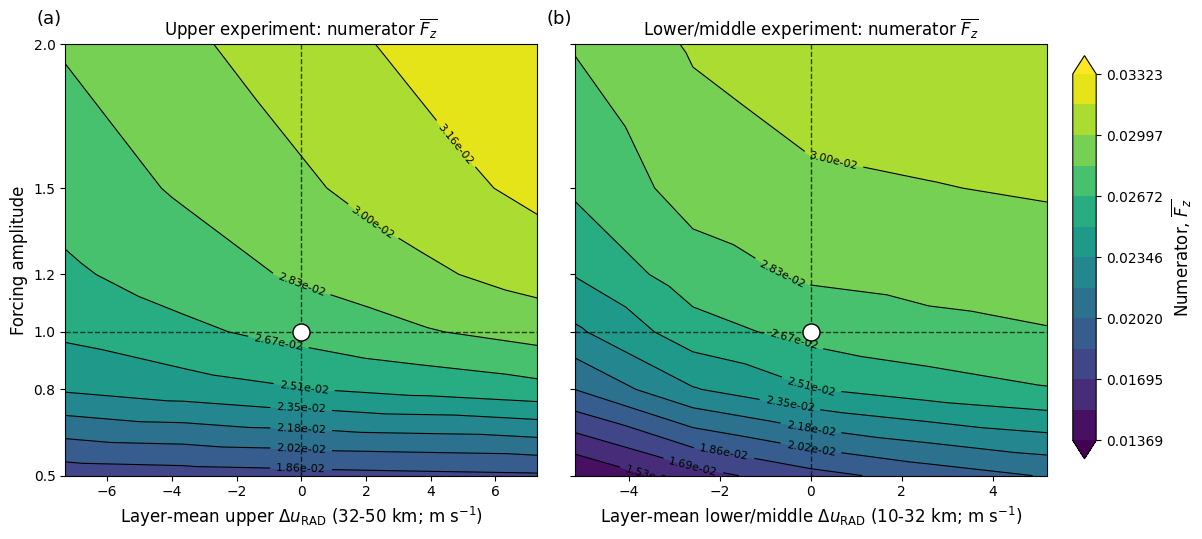

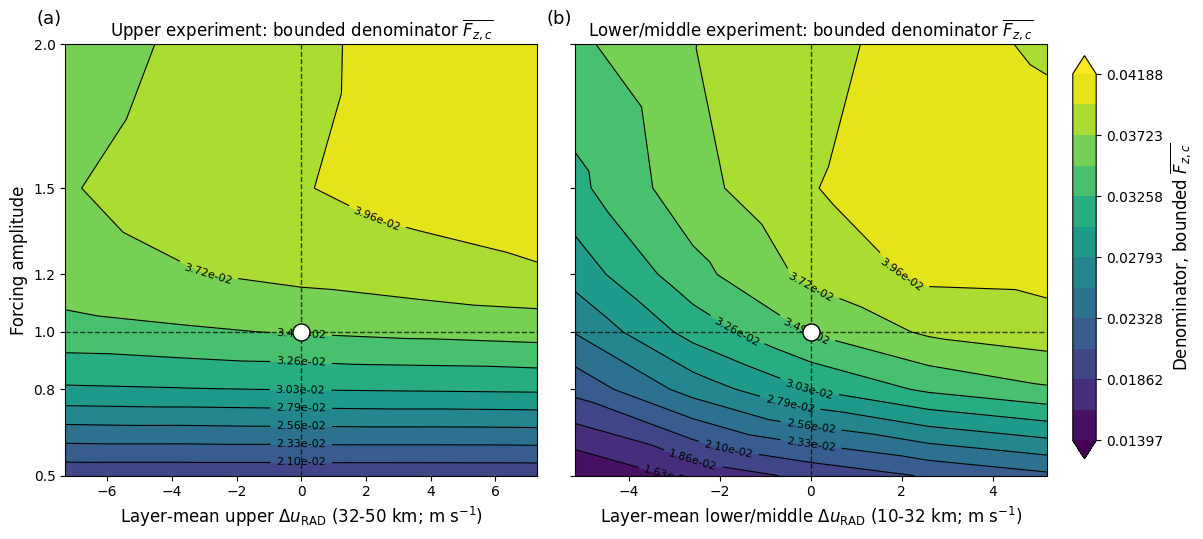

[DONE] Numerator and denominator output finished.


In [17]:
# %%
# ============================================================
# 7) Output numerator and denominator separately
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load capacity results if they are not already in memory
# ------------------------------------------------------------

def load_capacity_npz(path):
    data = np.load(path)
    return {k: data[k] for k in data.files}


if "alpha_capacity" not in globals():
    alpha_capacity = load_capacity_npz(os.path.join(SAVE_DIR, "alpha_capacity_scan.npz"))

if "shear_capacity" not in globals():
    shear_capacity = load_capacity_npz(os.path.join(SAVE_DIR, "shear_capacity_scan.npz"))


# ------------------------------------------------------------
# 2. Print matrices: numerator, denominator, ratio
# ------------------------------------------------------------

def print_capacity_components(label, cap):
    print("\n" + "=" * 90)
    print(label)
    print("=" * 90)

    print("\nForcing values:")
    print(cap["forcing_values"])

    print("\nParameter values:")
    print(cap["param_values"])

    print("\nNumerator: <Fz>_DJFM,10hPa")
    print(cap["fz_mean_mat"])

    print("\nDenominator: <Fzc>_DJFM,10hPa, bounded carrying capacity")
    print(cap["fzc_bounded_mean_mat"])

    print("\nDenominator: <Fzc>_DJFM,10hPa, unbounded quadratic maximum")
    print(cap["fzc_unbounded_mean_mat"])

    print("\nRatio: <Fz>/<Fzc>, bounded")
    print(cap["ratio_bounded_mat"])

    print("\nRatio: <Fz>/<Fzc>, unbounded")
    print(cap["ratio_unbounded_mat"])


print_capacity_components("Upper experiment / alpha_capacity", alpha_capacity)
print_capacity_components("Lower-middle experiment / shear_capacity", shear_capacity)


# ------------------------------------------------------------
# 3. Save long-table CSV for easier checking
# ------------------------------------------------------------

def capacity_to_long_dataframe(cap, experiment_name, param_label):
    rows = []

    forcing_values = np.asarray(cap["forcing_values"], dtype=float)
    param_values = np.asarray(cap["param_values"], dtype=float)

    for i, forcing in enumerate(forcing_values):
        for j, param in enumerate(param_values):
            fz = cap["fz_mean_mat"][i, j]
            fzc_bounded = cap["fzc_bounded_mean_mat"][i, j]
            fzc_unbounded = cap["fzc_unbounded_mean_mat"][i, j]

            ratio_bounded = cap["ratio_bounded_mat"][i, j]
            ratio_unbounded = cap["ratio_unbounded_mat"][i, j]

            rows.append({
                "experiment": experiment_name,
                param_label: param,
                "forcing_amplitude": forcing,
                "Fz_numerator_mean": fz,
                "Fzc_denominator_bounded_mean": fzc_bounded,
                "Fzc_denominator_unbounded_mean": fzc_unbounded,
                "ratio_bounded": ratio_bounded,
                "ratio_unbounded": ratio_unbounded,
                "n_members": cap["nmem_mat"][i, j],
            })

    return pd.DataFrame(rows)


df_upper = capacity_to_long_dataframe(
    alpha_capacity,
    experiment_name="upper",
    param_label="gamma_upper",
)

df_lowmid = capacity_to_long_dataframe(
    shear_capacity,
    experiment_name="lower_middle",
    param_label="gamma_lowmid",
)

df_components = pd.concat([df_upper, df_lowmid], ignore_index=True)

csv_path = os.path.join(SAVE_DIR, "carrying_capacity_numerator_denominator.csv")
df_components.to_csv(csv_path, index=False)

print("\nSaved numerator/denominator table to:")
print(csv_path)

display(df_components)


# ------------------------------------------------------------
# 4. Print the control-run values explicitly
#    Control = forcing amplitude 1.0, parameter value 0.0
# ------------------------------------------------------------

def print_control_values(cap, label):
    forcing_values = np.asarray(cap["forcing_values"], dtype=float)
    param_values = np.asarray(cap["param_values"], dtype=float)

    i0 = np.argmin(np.abs(forcing_values - 1.0))
    j0 = np.argmin(np.abs(param_values - 0.0))

    print("\n" + "-" * 80)
    print(f"{label} control-like point")
    print("-" * 80)
    print("forcing =", forcing_values[i0])
    print("parameter =", param_values[j0])
    print("<Fz> numerator =", cap["fz_mean_mat"][i0, j0])
    print("<Fzc> denominator, bounded =", cap["fzc_bounded_mean_mat"][i0, j0])
    print("<Fzc> denominator, unbounded =", cap["fzc_unbounded_mean_mat"][i0, j0])
    print("<Fz>/<Fzc>, bounded =", cap["ratio_bounded_mat"][i0, j0])
    print("<Fz>/<Fzc>, unbounded =", cap["ratio_unbounded_mat"][i0, j0])


print_control_values(alpha_capacity, "Upper experiment")
print_control_values(shear_capacity, "Lower-middle experiment")


# ------------------------------------------------------------
# 5. Optional: plot numerator and denominator separately
# ------------------------------------------------------------

def plot_component_like_fig14(
    du_upper_mat,
    du_lowmid_mat,
    forcing_values_alpha,
    forcing_values_shear,
    upper_mat,
    lowmid_mat,
    colorbar_label,
    title_suffix,
    save_name,
    cmap="viridis",
    levels=13,
):
    vmin = np.nanmin([np.nanmin(upper_mat), np.nanmin(lowmid_mat)])
    vmax = np.nanmax([np.nanmax(upper_mat), np.nanmax(lowmid_mat)])
    level_values = np.linspace(vmin, vmax, levels)

    Y_upper = np.repeat(forcing_values_alpha[:, None], du_upper_mat.shape[1], axis=1)
    Y_lowmid = np.repeat(forcing_values_shear[:, None], du_lowmid_mat.shape[1], axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), sharey=True)

    # upper
    x1 = du_upper_mat.flatten()
    y1 = Y_upper.flatten()
    z1 = upper_mat.flatten()
    valid1 = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(z1)

    cf1 = axes[0].tricontourf(
        x1[valid1], y1[valid1], z1[valid1],
        levels=level_values, cmap=cmap, extend="both"
    )
    cs1 = axes[0].tricontour(
        x1[valid1], y1[valid1], z1[valid1],
        levels=level_values, colors="k", linewidths=0.8
    )
    axes[0].clabel(cs1, inline=True, fontsize=8, fmt="%.2e")

    axes[0].axvline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    axes[0].axhline(1, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    axes[0].scatter(0, 1, s=150, facecolor="white", edgecolor="black", linewidth=1.0, zorder=12)

    axes[0].set_xlabel(
        rf"Layer-mean upper $\Delta u_{{\mathrm{{RAD}}}}$ "
        rf"({UPPER_ZMIN:.0f}-{UPPER_ZMAX:.0f} km; m s$^{{-1}}$)",
        fontsize=12,
    )
    axes[0].set_ylabel("Forcing amplitude", fontsize=12)
    axes[0].set_title("Upper experiment: " + title_suffix, fontsize=12)
    axes[0].set_yticks(forcing_values_alpha)
    axes[0].text(-0.06, 1.08, "(a)", transform=axes[0].transAxes,
                 fontsize=13, va="top", ha="left")

    # lower/middle
    x2 = du_lowmid_mat.flatten()
    y2 = Y_lowmid.flatten()
    z2 = lowmid_mat.flatten()
    valid2 = np.isfinite(x2) & np.isfinite(y2) & np.isfinite(z2)

    cf2 = axes[1].tricontourf(
        x2[valid2], y2[valid2], z2[valid2],
        levels=level_values, cmap=cmap, extend="both"
    )
    cs2 = axes[1].tricontour(
        x2[valid2], y2[valid2], z2[valid2],
        levels=level_values, colors="k", linewidths=0.8
    )
    axes[1].clabel(cs2, inline=True, fontsize=8, fmt="%.2e")

    axes[1].axvline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    axes[1].axhline(1, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    axes[1].scatter(0, 1, s=150, facecolor="white", edgecolor="black", linewidth=1.0, zorder=12)

    axes[1].set_xlabel(
        rf"Layer-mean lower/middle $\Delta u_{{\mathrm{{RAD}}}}$ "
        rf"({LOWMID_ZMIN:.0f}-{LOWMID_ZMAX:.0f} km; m s$^{{-1}}$)",
        fontsize=12,
    )
    axes[1].set_title("Lower/middle experiment: " + title_suffix, fontsize=12)
    axes[1].set_yticks(forcing_values_shear)
    axes[1].text(-0.06, 1.08, "(b)", transform=axes[1].transAxes,
                 fontsize=13, va="top", ha="left")

    fig.subplots_adjust(right=0.88, wspace=0.08)
    cax = fig.add_axes([0.90, 0.14, 0.018, 0.72])
    cbar = fig.colorbar(cf2, cax=cax)
    cbar.set_label(colorbar_label, fontsize=12)

    fig.savefig(save_name, dpi=600, bbox_inches="tight")
    plt.show()

    return fig


# Make sure these coordinates exist. If not, recompute them.
if "du_upper_mat" not in globals() or "du_lowmid_mat" not in globals():
    alpha_values, forcing_values_alpha, alpha_mean, alpha_std, alpha_nmem = load_scan_result(ALPHA_SCAN_FILE)
    shear_values, forcing_values_shear, shear_mean, shear_std, shear_nmem = load_scan_result(SHEAR_SCAN_FILE)

    du_upper_mat, du_lowmid_mat = compute_delta_urad_coordinates(
        alpha_values=alpha_values,
        forcing_values_alpha=forcing_values_alpha,
        shear_values=shear_values,
        forcing_values_shear=forcing_values_shear,
    )


# Plot numerator <Fz>
plot_component_like_fig14(
    du_upper_mat=du_upper_mat,
    du_lowmid_mat=du_lowmid_mat,
    forcing_values_alpha=alpha_capacity["forcing_values"],
    forcing_values_shear=shear_capacity["forcing_values"],
    upper_mat=alpha_capacity["fz_mean_mat"],
    lowmid_mat=shear_capacity["fz_mean_mat"],
    colorbar_label=r"Numerator, $\overline{F_z}$",
    title_suffix=r"numerator $\overline{F_z}$",
    save_name="para_sweep_Fz_numerator.png",
    cmap="viridis",
    levels=13,
)

# Plot bounded denominator <Fzc>
plot_component_like_fig14(
    du_upper_mat=du_upper_mat,
    du_lowmid_mat=du_lowmid_mat,
    forcing_values_alpha=alpha_capacity["forcing_values"],
    forcing_values_shear=shear_capacity["forcing_values"],
    upper_mat=alpha_capacity["fzc_bounded_mean_mat"],
    lowmid_mat=shear_capacity["fzc_bounded_mean_mat"],
    colorbar_label=r"Denominator, bounded $\overline{F_{z,c}}$",
    title_suffix=r"bounded denominator $\overline{F_{z,c}}$",
    save_name="para_sweep_Fzc_denominator_bounded.png",
    cmap="viridis",
    levels=13,
)

print("[DONE] Numerator and denominator output finished.")

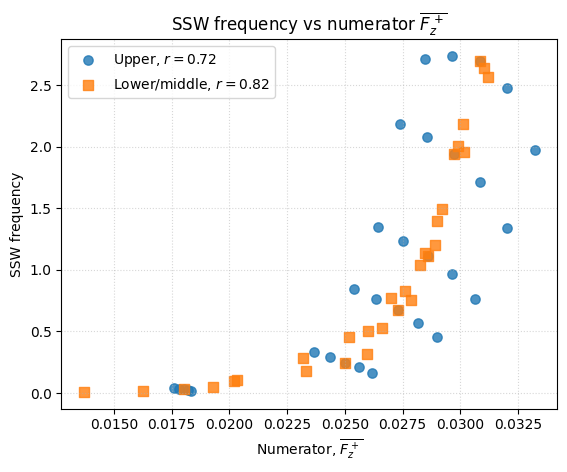

Correlation between numerator <Fz+> and SSW frequency:
  upper        r = 0.715236457647432
  lower/middle r = 0.8175793374898891
  all          r = 0.7653385604972364

Linear fit, combined:
  slope     = 147.7197010727698
  intercept = -2.8579701136949236


In [18]:
# %%
# ============================================================
# Scatter: numerator <Fz> vs SSW frequency
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

def linear_fit_valid(x, y):
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)

    valid = np.isfinite(x) & np.isfinite(y)
    x_valid = x[valid]
    y_valid = y[valid]

    if x_valid.size < 2:
        return np.nan, np.nan, np.nan, x_valid, y_valid

    # Pearson r
    r = pearson_r(x_valid, y_valid)

    # linear fit y = slope*x + intercept
    slope, intercept = np.polyfit(x_valid, y_valid, 1)

    return r, slope, intercept, x_valid, y_valid


def plot_fz_numerator_vs_ssw(
    upper_fz_mat,
    lowmid_fz_mat,
    upper_ssw_mat,
    lowmid_ssw_mat,
    save_name="Fz_numerator_vs_SSW_frequency.png",
):
    # upper
    r_upper, slope_u, intercept_u, x_u, y_u = linear_fit_valid(
        upper_fz_mat, upper_ssw_mat
    )

    # lower/middle
    r_lowmid, slope_l, intercept_l, x_l, y_l = linear_fit_valid(
        lowmid_fz_mat, lowmid_ssw_mat
    )

    # combined
    x_all_raw = np.concatenate([
        np.asarray(upper_fz_mat).reshape(-1),
        np.asarray(lowmid_fz_mat).reshape(-1),
    ])
    y_all_raw = np.concatenate([
        np.asarray(upper_ssw_mat).reshape(-1),
        np.asarray(lowmid_ssw_mat).reshape(-1),
    ])

    r_all, slope_all, intercept_all, x_all, y_all = linear_fit_valid(
        x_all_raw, y_all_raw
    )

    fig, ax = plt.subplots(figsize=(6.4, 4.8))

    ax.scatter(
        x_u,
        y_u,
        s=45,
        alpha=0.8,
        label=fr"Upper, $r={r_upper:.2f}$"
    )

    ax.scatter(
        x_l,
        y_l,
        s=45,
        alpha=0.8,
        marker="s",
        label=fr"Lower/middle, $r={r_lowmid:.2f}$"
    )

    # # combined linear fit
    # if np.isfinite(slope_all):
    #     xfit = np.linspace(np.nanmin(x_all), np.nanmax(x_all), 200)
    #     yfit = slope_all * xfit + intercept_all

    #     ax.plot(
    #         xfit,
    #         yfit,
    #         linewidth=2.0,
    #         linestyle="--",
    #         label=fr"Combined fit, $r={r_all:.2f}$"
    #     )

    ax.set_xlabel(r"Numerator, $\overline{F_z^+}$")
    ax.set_ylabel("SSW frequency")
    ax.set_title(r"SSW frequency vs numerator $\overline{F_z^+}$")
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend(fontsize=10)

    fig.savefig(save_name, dpi=600, bbox_inches="tight")
    plt.show()

    print("Correlation between numerator <Fz+> and SSW frequency:")
    print("  upper        r =", r_upper)
    print("  lower/middle r =", r_lowmid)
    print("  all          r =", r_all)
    print("")
    print("Linear fit, combined:")
    print("  slope     =", slope_all)
    print("  intercept =", intercept_all)

    return fig


# ------------------------------------------------------------
# Use current numerator matrices
# ------------------------------------------------------------

upper_fz_num = alpha_capacity["fz_mean_mat"]
lowmid_fz_num = shear_capacity["fz_mean_mat"]

fig = plot_fz_numerator_vs_ssw(
    upper_fz_mat=upper_fz_num,
    lowmid_fz_mat=lowmid_fz_num,
    upper_ssw_mat=alpha_mean,
    lowmid_ssw_mat=shear_mean,
    save_name="Fz_numerator_vs_SSW_frequency.png",
)

In [19]:
# %%
# ============================================================
# Alternative carrying-capacity diagnostic based on simple Eq. 6:
#
#     Fz = C exp(-z/H) ubar A
#
# with uref = ubar + alpha A.
#
# Maximum under fixed uref:
#
#     Fzc = C exp(-z/H) uref^2 / (4 alpha)
# ============================================================

USE_POSITIVE_SIMPLE_FZ = True

def compute_fz_actual_fortran(uref, a, ucos, z_km):
    """
    Re-define actual Fz using the simple manuscript Eq. 6:

        Fz = C * exp(-z/H) * ubar * A

    Here:
        ucos is the 10-hPa ubar time series,
        a is the saved FAWA A,
        fact = exp(-z/H).

    The function name is kept the same so the existing scan code can
    be reused without changing compute_member_capacity_diagnostic().
    """
    ubar = np.asarray(ucos, dtype=float)
    A = np.asarray(a, dtype=float)

    fact = get_fact_at_level(z_km)

    fz_raw = C1_CONST * fact * ubar * A

    if USE_POSITIVE_SIMPLE_FZ:
        fz = np.where(fz_raw < 0.0, 0.0, fz_raw)
    else:
        fz = fz_raw

    # Return placeholders for compatibility with existing code.
    sigma_dummy = np.full_like(fz, np.nan)
    switch_dummy = np.full_like(fz, np.nan)
    base_wind = ubar

    return fz, sigma_dummy, switch_dummy, fact, base_wind


def compute_fz_capacity_fortran(uref, a, z_km, bounded=True):
    """
    Re-define carrying capacity from the simple manuscript Eq. 6:

        Fz = C * exp(-z/H) * ubar * A

    with

        uref = ubar + alpha A.

    For fixed uref, maximize

        (uref - alpha A) A

    over A. The maximum occurs at

        A_c = uref / (2 alpha),
        ubar_c = uref / 2,

    giving

        Fzc = C * exp(-z/H) * uref^2 / (4 alpha).

    The bounded argument is ignored here, because this definition has
    no empirical sigma bound.
    """
    uref = np.asarray(uref, dtype=float)
    A = np.asarray(a, dtype=float)

    fact = get_fact_at_level(z_km)

    if ALPHA_MODEL <= 0:
        raise ValueError("ALPHA_MODEL must be positive for simple Eq. 6 carrying capacity.")

    fzc = C1_CONST * fact * (uref ** 2) / (4.0 * ALPHA_MODEL)

    # Optional physical guard: if uref is nonpositive, the positive
    # carrying capacity is not meaningful.
    fzc = np.where(uref > 0.0, fzc, np.nan)

    sigma_c_dummy = uref / (2.0 * ALPHA_MODEL)
    base_wind = uref / 2.0

    return fzc, sigma_c_dummy, fact, base_wind


print("Using simple Eq. 6 carrying-capacity definition:")
print("  Fz  = C exp(-z/H) ubar A")
print("  Fzc = C exp(-z/H) uref^2 / (4 alpha)")

Using simple Eq. 6 carrying-capacity definition:
  Fz  = C exp(-z/H) ubar A
  Fzc = C exp(-z/H) uref^2 / (4 alpha)


[INFO] alpha_capacity_scan_simple_eq6: param=-0.400, dir=output_sweep_a_n40
  [INFO] forcing=0.50, members=10


    [ens00] Fz/Fzc bounded=0.4312, unbounded=0.4312, Fz=1.7482e-02
    [ens01] Fz/Fzc bounded=0.4301, unbounded=0.4301, Fz=1.7414e-02
    [ens02] Fz/Fzc bounded=0.4255, unbounded=0.4255, Fz=1.7283e-02
    [ens03] Fz/Fzc bounded=0.4227, unbounded=0.4227, Fz=1.7191e-02
    [ens04] Fz/Fzc bounded=0.4277, unbounded=0.4277, Fz=1.7384e-02
    [ens05] Fz/Fzc bounded=0.4263, unbounded=0.4263, Fz=1.7307e-02
    [ens06] Fz/Fzc bounded=0.4285, unbounded=0.4285, Fz=1.7369e-02
    [ens07] Fz/Fzc bounded=0.4299, unbounded=0.4299, Fz=1.7413e-02
    [ens08] Fz/Fzc bounded=0.4198, unbounded=0.4198, Fz=1.7120e-02
    [ens09] Fz/Fzc bounded=0.4256, unbounded=0.4256, Fz=1.7310e-02
  [DONE] mean bounded ratio=0.4267, unbounded ratio=0.4267, n=10
  [INFO] forcing=0.80, members=10
    [ens00] Fz/Fzc bounded=0.6340, unbounded=0.6340, Fz=2.2341e-02
    [ens01] Fz/Fzc bounded=0.6268, unbounded=0.6268, Fz=2.2174e-02
    [ens02] Fz/Fzc bounded=0.6346, unbounded=0.6346, Fz=2.2261e-02
    [ens03] Fz/Fzc bounded=0.6

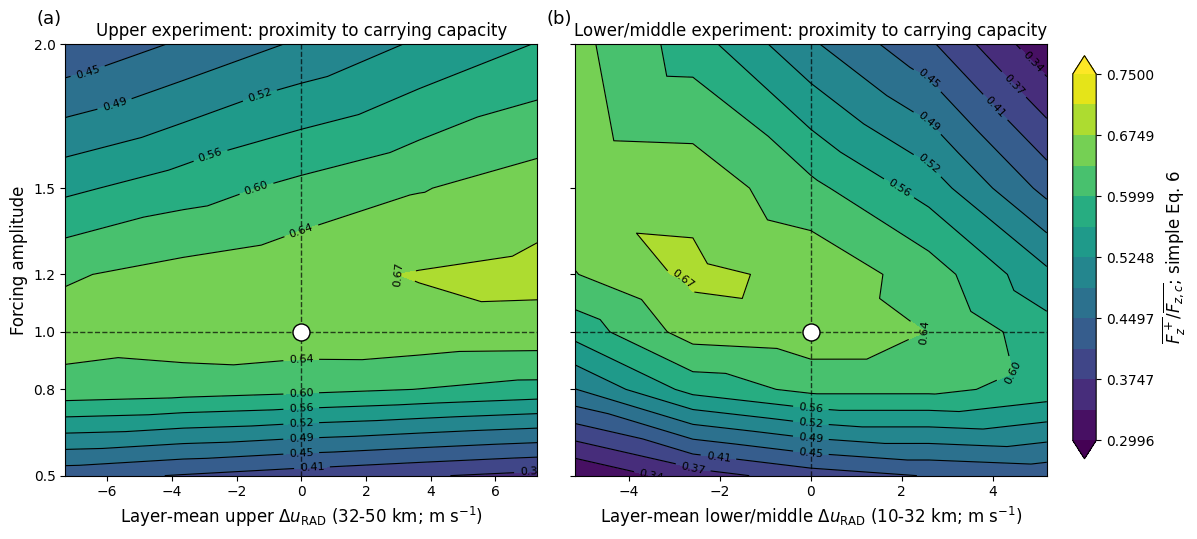

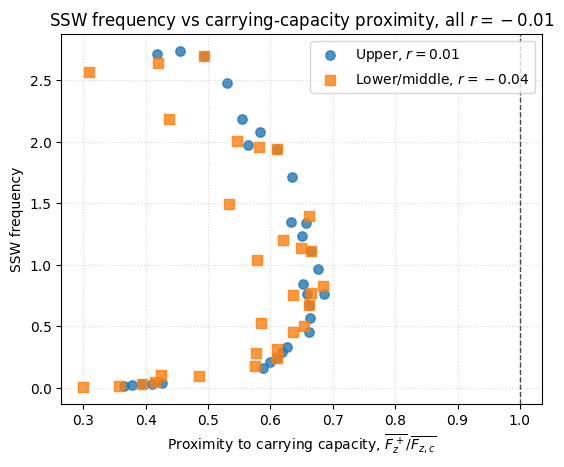

Pearson r, upper = 0.0113
Pearson r, lower/middle = -0.0446
Pearson r, all = -0.0110


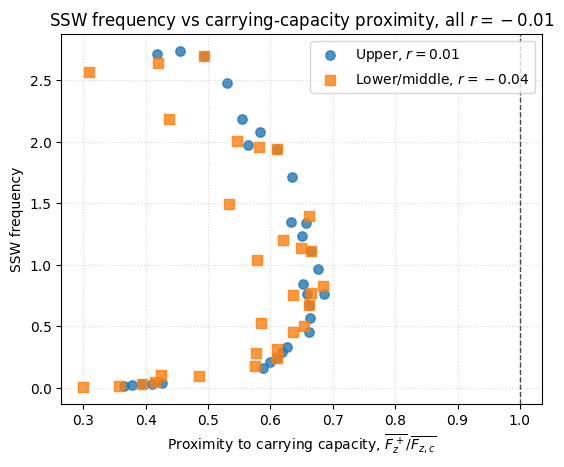

In [20]:
# %%
# ============================================================
# Re-scan using simple Eq. 6 carrying capacity
# ============================================================

alpha_capacity_simple = scan_capacity_grid(
    root=ROOT,
    param_dir_map=ALPHA_DIR_MAP,
    forcing_dirs=FORCING_DIRS,
    scan_name="alpha_capacity_scan_simple_eq6",
    verbose=True,
)

shear_capacity_simple = scan_capacity_grid(
    root=ROOT,
    param_dir_map=SHEAR_DIR_MAP,
    forcing_dirs=FORCING_DIRS,
    scan_name="shear_capacity_scan_simple_eq6",
    verbose=True,
)

# Load SSW frequency and coordinates
alpha_values, forcing_values_alpha, alpha_mean, alpha_std, alpha_nmem = load_scan_result(ALPHA_SCAN_FILE)
shear_values, forcing_values_shear, shear_mean, shear_std, shear_nmem = load_scan_result(SHEAR_SCAN_FILE)

du_upper_mat, du_lowmid_mat = compute_delta_urad_coordinates(
    alpha_values=alpha_values,
    forcing_values_alpha=forcing_values_alpha,
    shear_values=shear_values,
    forcing_values_shear=forcing_values_shear,
)

# In this simple definition, bounded/unbounded are identical.
upper_ratio_simple = alpha_capacity_simple["ratio_unbounded_mat"]
lowmid_ratio_simple = shear_capacity_simple["ratio_unbounded_mat"]

print("Simple Eq. 6 ratio range:")
print("Upper:", np.nanmin(upper_ratio_simple), np.nanmax(upper_ratio_simple))
print("Lower/middle:", np.nanmin(lowmid_ratio_simple), np.nanmax(lowmid_ratio_simple))

print("Correlation with SSW frequency:")
print("  upper        r =", pearson_r(upper_ratio_simple, alpha_mean))
print("  lower/middle r =", pearson_r(lowmid_ratio_simple, shear_mean))
print("  all          r =", pearson_r(
    np.concatenate([upper_ratio_simple.reshape(-1), lowmid_ratio_simple.reshape(-1)]),
    np.concatenate([alpha_mean.reshape(-1), shear_mean.reshape(-1)])
))

plot_capacity_ratio_like_fig14(
    du_upper_mat=du_upper_mat,
    du_lowmid_mat=du_lowmid_mat,
    forcing_values_alpha=forcing_values_alpha,
    forcing_values_shear=forcing_values_shear,
    upper_ratio_mat=upper_ratio_simple,
    lowmid_ratio_mat=lowmid_ratio_simple,
    ratio_label=r"$\overline{F_z^+}/\overline{F_{z,c}}$; simple Eq. 6",
    cmap="viridis",
    levels=13,
    save_name="para_sweep_simple_eq6_Fz_over_capacity.png",
)

plot_ratio_vs_ssw_scatter(
    upper_ratio_mat=upper_ratio_simple,
    lowmid_ratio_mat=lowmid_ratio_simple,
    upper_ssw_mat=alpha_mean,
    lowmid_ssw_mat=shear_mean,
    save_name="simple_eq6_Fz_ratio_vs_ssw_frequency.png",
)

In [21]:
# # %%
# # ============================================================
# # Plot Fz time series for one control run
# # ============================================================

# import os
# import numpy as np
# import matplotlib.pyplot as plt

# # ------------------------------------------------------------
# # 1. Choose one control run
# # ------------------------------------------------------------

# CONTROL_ENS_DIR = os.path.join(
#     ROOT,
#     "output_sweep_a_n40",     # gamma_upper = 0, gamma_lowmid = 0
#     "scale_1p50",       # forcing amplitude = 1.0
#     "ens02"             # choose one ensemble member
# )

# YEAR_TO_PLOT = 0        # choose model year: 0 to 999

# print("Control run directory:")
# print(CONTROL_ENS_DIR)

# # ------------------------------------------------------------
# # 2. Read u, A, uref and reconstruct Fz
# # ------------------------------------------------------------

# uout_file = find_nc_file(CONTROL_ENS_DIR, "uout")
# aout_file = find_nc_file(CONTROL_ENS_DIR, "aout")
# urout_file = find_nc_file(CONTROL_ENS_DIR, "urout")

# print("uout:", uout_file)
# print("aout:", aout_file)
# print("urout:", urout_file)

# ubar_raw, u_name = read_var_from_file(uout_file, UBAR_CANDIDATES)
# a_raw, a_name = read_var_from_file(aout_file, A_CANDIDATES)
# uref_raw, uref_name = read_var_from_file(urout_file, UREF_CANDIDATES)

# expected_len = YR * N_PER_YEAR

# ucos = extract_level_timeseries(
#     ubar_raw,
#     LEVEL_INDEX_10HPA,
#     expected_len=expected_len
# )

# a = extract_level_timeseries(
#     a_raw,
#     LEVEL_INDEX_10HPA,
#     expected_len=expected_len
# )

# uref = extract_level_timeseries(
#     uref_raw,
#     LEVEL_INDEX_10HPA,
#     expected_len=expected_len
# )

# z_km = get_level_height_km(uout_file, LEVEL_INDEX_10HPA)

# fz, sigma, switch, fact, base_wind = compute_fz_actual_fortran(
#     uref=uref,
#     a=a,
#     ucos=ucos,
#     z_km=z_km,
# )

# fzc_bounded, sigma_c_bounded, _, _ = compute_fz_capacity_fortran(
#     uref=uref,
#     a=a,
#     z_km=z_km,
#     bounded=True,
# )

# print("\nVariables used:")
# print("u variable:", u_name)
# print("A variable:", a_name)
# print("uref variable:", uref_name)
# print("z_km:", z_km)
# print("fact:", fact)

# # ------------------------------------------------------------
# # 3. Reshape to year x seasonal time
# # ------------------------------------------------------------

# fz_2d = fz.reshape(YR, N_PER_YEAR)
# fzc_2d = fzc_bounded.reshape(YR, N_PER_YEAR)
# sigma_2d = sigma.reshape(YR, N_PER_YEAR)
# switch_2d = switch.reshape(YR, N_PER_YEAR)

# # model seasonal day axis: Oct 1 to approximately May/June
# days_per_step = (DMAX_REF / N_PER_YEAR) / 4.0
# day_axis = np.arange(N_PER_YEAR) * days_per_step

# djfm_idx = djfm_indices(N_PER_YEAR)
# djfm_start = djfm_idx[0]
# djfm_end = djfm_idx[-1]

# # ------------------------------------------------------------
# # 4. Print basic diagnostics
# # ------------------------------------------------------------

# fz_djfm = fz_2d[:, djfm_idx].reshape(-1)
# fzc_djfm = fzc_2d[:, djfm_idx].reshape(-1)

# print("\nDJFM diagnostics:")
# print("mean Fz =", np.nanmean(fz_djfm))
# print("mean Fzc =", np.nanmean(fzc_djfm))
# print("mean Fz/Fzc =", np.nanmean(fz_djfm) / np.nanmean(fzc_djfm))
# print("fraction Fz < 0 =", np.mean(fz_djfm < 0))
# print("min Fz =", np.nanmin(fz_djfm))
# print("max Fz =", np.nanmax(fz_djfm))

# # ------------------------------------------------------------
# # 5. Plot one selected year
# # ------------------------------------------------------------

# fig, ax = plt.subplots(figsize=(8.0, 4.2))

# ax.plot(
#     day_axis,
#     fz_2d[YEAR_TO_PLOT, :],
#     linewidth=2.0,
#     label=r"$F_z$"
# )

# ax.plot(
#     day_axis,
#     fzc_2d[YEAR_TO_PLOT, :],
#     linewidth=2.0,
#     linestyle="--",
#     label=r"$F_{z,c}$"
# )

# ax.axhline(0, color="k", linewidth=1.0, linestyle=":")
# ax.axvspan(
#     day_axis[djfm_start],
#     day_axis[djfm_end],
#     alpha=0.15,
#     label="DJFM"
# )

# ax.set_xlabel("Days since Oct 1")
# ax.set_ylabel(r"Flux at 10 hPa")
# ax.set_title(
#     rf"Control run, ens00, year {YEAR_TO_PLOT}: reconstructed $F_z$ at 10 hPa"
# )
# ax.grid(True, linestyle=":", alpha=0.5)
# ax.legend()

# fig.savefig(
#     f"control_ens00_year{YEAR_TO_PLOT:04d}_Fz_timeseries.png",
#     dpi=600,
#     bbox_inches="tight"
# )

# plt.show()

# # ------------------------------------------------------------
# # 6. Plot seasonal climatology over all 1000 years
# # ------------------------------------------------------------

# fz_clim = np.nanmean(fz_2d, axis=0)
# fzc_clim = np.nanmean(fzc_2d, axis=0)

# fz_p10 = np.nanpercentile(fz_2d, 10, axis=0)
# fz_p90 = np.nanpercentile(fz_2d, 90, axis=0)

# fig, ax = plt.subplots(figsize=(8.0, 4.2))

# ax.plot(
#     day_axis,
#     fz_clim,
#     linewidth=2.5,
#     label=r"$\overline{F_z}$ seasonal mean"
# )

# ax.fill_between(
#     day_axis,
#     fz_p10,
#     fz_p90,
#     alpha=0.25,
#     label=r"$F_z$ 10--90 percentile"
# )

# ax.plot(
#     day_axis,
#     fzc_clim,
#     linewidth=2.5,
#     linestyle="--",
#     label=r"$\overline{F_{z,c}}$ seasonal mean"
# )

# ax.axhline(0, color="k", linewidth=1.0, linestyle=":")
# ax.axvspan(
#     day_axis[djfm_start],
#     day_axis[djfm_end],
#     alpha=0.15,
#     label="DJFM"
# )

# ax.set_xlabel("Days since Oct 1")
# ax.set_ylabel(r"Flux at 10 hPa")
# ax.set_title(r"Control run, ens00: seasonal evolution of $F_z$ and $F_{z,c}$")
# ax.grid(True, linestyle=":", alpha=0.5)
# ax.legend()

# fig.savefig(
#     "control_ens00_Fz_seasonal_climatology.png",
#     dpi=600,
#     bbox_inches="tight"
# )

# plt.show()

# # ------------------------------------------------------------
# # 7. Plot DJFM distribution of Fz
# # ------------------------------------------------------------

# fig, ax = plt.subplots(figsize=(6.5, 4.2))

# ax.hist(
#     fz_djfm[np.isfinite(fz_djfm)],
#     bins=80,
#     alpha=0.8
# )

# ax.axvline(0, color="k", linewidth=1.2, linestyle="--")
# ax.axvline(np.nanmean(fz_djfm), color="k", linewidth=2.0)

# ax.set_xlabel(r"DJFM $F_z$ at 10 hPa")
# ax.set_ylabel("Count")
# ax.set_title(
#     r"Control run, ens00: DJFM distribution of reconstructed $F_z$"
# )
# ax.grid(True, linestyle=":", alpha=0.5)

# fig.savefig(
#     "control_ens00_DJFM_Fz_distribution.png",
#     dpi=600,
#     bbox_inches="tight"
# )

# plt.show()